In [1]:
import json
import os
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cm
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dask.diagnostics.progress import ProgressBar
from matplotlib.ticker import FixedLocator, MaxNLocator, ScalarFormatter
from xarrayutils.plotting import box_plot, linear_piecewise_scale

%matplotlib inline

In [2]:
# Create directory
dataset_name = "OM4"

pred_dict = {}
pred_dict["pred_1"] = {
    "name": "samudra-trained-on-halfdeg-om4-10y-test-on-om4",
    "run_name": "samudra-trained-on-halfdeg-om4-10y-test-on-om4",
    "path": "/Users/jder/oa/Ocean_Emulator/.LOCAL/samudra-trained-on-halfdeg-om4-10y-test-on-om4/predictions.zarr",
    "ls": ["thetao", "so", "uo", "vo", "tos", "zos"],
}

# pred_dict["pred_2"] = {
#     "name": "samudra-trained-on-cm4-with-om4-configs-test-on-om4",
#     "run_name": "samudra-trained-on-cm4-with-om4-configs-test-on-om4",
#     "path": "/pscratch/sd/s/suryad/Ocean_Emulator/.LOCAL/2025-04-05-eval-samudra-cm4-trained-on-om4-configs-test-on-om4/predictions.zarr",
#     "ls": ["thetao", "so", "uo", "vo", "tos", "zos"],
# }

key1 = list(pred_dict.keys())[0]
levels = 19

output_path = (
    "/Users/jder/oa/Ocean_Emulator/temp/outputs/"
    + str(datetime.now())[:10]
    + "_"
    + "_".join([pred_dict[k]["run_name"] for k in pred_dict.keys()])
)

In [3]:
# [Optional] Convert nc files to zarr
# ds_prediction = xr.open_dataset('/pscratch/sd/s/suryad/Ocean_Emulator/temp/ai2_samudra/autoregressive_predictions.nc', engine='netcdf4').isel(sample=0)
# ds_prediction = ds_prediction.chunk({'time': 10, 'lat': 180, 'lon': 360})
# ds_prediction.to_zarr('/pscratch/sd/s/suryad/Ocean_Emulator/temp/ai2_samudra/autoregressive_predictions.zarr', encoding={var: {'compressor': None} for var in ds_prediction.data_vars}, mode='w')

# ds_groundtruth = xr.open_dataset('/pscratch/sd/s/suryad/Ocean_Emulator/temp/ai2_samudra/autoregressive_target.nc', engine='netcdf4').isel(sample=0)
# ds_groundtruth = ds_groundtruth.chunk({'lat': 180, 'lon': 360, 'time': 10})
# ds_groundtruth.to_zarr('/pscratch/sd/s/suryad/Ocean_Emulator/temp/ai2_samudra/autoregressive_groundtruth.zarr', encoding={var: {'compressor': None} for var in ds_prediction.data_vars}, mode='w')

# More assertion
# np.allclose(ds_groundtruth_saved.isel(time=slice(None,10)).fillna(0).to_array().to_numpy(), ds_groundtruth[list(ds_groundtruth_saved.data_vars.keys())].isel(time=slice(-ds_groundtruth_saved.time.size, None)).isel(time=slice(None,10)).fillna(0).to_array().to_numpy())

In [4]:
from copy import deepcopy

import xarray as xr
from ocean_emulators.constants import DEPTH_LEVELS, DEPTH_THICKNESS


def rename_vars(data: xr.Dataset) -> xr.Dataset:
    """
    Rename variables if required.
    """
    for var_str in data.variables:
        # OM4 data format has variables in the form: var_lev_depthlevel
        # ex. so_lev_1040_0. We need to convert into var_depthlevelidx
        if "_lev_" in var_str:
            var_split = var_str.split("_lev_")
            var = var_split[0]
            lev_in_depth = float(var_split[1].replace("_", "."))
            lev_in_depth_idx = DEPTH_LEVELS.index(lev_in_depth)
            data = data.rename({var_str: var + "_" + str(lev_in_depth_idx)})
    return data


def _combine_variables_by_level(ds, combine_vars):
    """
    Combine variables in the dataset along a new 'lev' dimension based on their suffix.

    Parameters:
    ds (xarray.Dataset): The input dataset containing variables with suffixes
                        (e.g., thetao_0, so_1).
    lev (xarray.DataArray): lev dataarray containing lev values
    combine_vars (list): List of variable prefixes to combine.

    Returns:
    xarray.Dataset: The dataset with combined variables and a new 'lev' dimension.
    """
    for v in combine_vars:
        level_numbers = [i for i in range(19)]
        sorted_vars = [v + "_" + str(lev) for lev in level_numbers]
        if sorted_vars[0] not in ds.data_vars:
            continue
        combined = xr.concat([ds[var] for var in sorted_vars], dim="lev")
        combined = combined.assign_coords(lev=DEPTH_LEVELS)
        ds[v] = combined
        ds = ds.drop_vars(sorted_vars)
    return ds


def combine_variables_by_level(ds_groundtruth, pred_dict, combine_ground=True):
    """
    Combine variables by level for ground truth and predictions.

    Parameters:
    ds_groundtruth (xarray.Dataset): The ground truth dataset.
    pred_dict (dict): Dictionary containing prediction datasets.

    Returns:
    xarray.Dataset, dict: Updated ground truth and prediction datasets.
    """
    if combine_ground:
        ds_groundtruth = _combine_variables_by_level(
            ds_groundtruth, ["thetao", "so", "uo", "vo", "mask"]
        )
    for key in pred_dict.keys():
        pred_dict[key]["ds_prediction"] = _combine_variables_by_level(
            pred_dict[key]["ds_prediction"], pred_dict[key]["ls"]
        )
    return ds_groundtruth, pred_dict


def _postprocess_for_plot(ds, areacello: np.ndarray, dz, times, wetmask, coords=None):
    """
    Postprocess the dataset to make it compatible with plotting functions.
    """
    ds = ds.transpose("time", "lev", ...)
    ds["time"] = times
    if coords is not None:
        ds = ds.assign_coords(coords)
    if "thetao" in ds.data_vars:
        ds["thetao"] = ds["thetao"].assign_attrs(
            long_name=r"${\theta_O}$", units=r"$\degree C$"
        )
    if "so" in ds.data_vars:
        ds["so"] = ds["so"].assign_attrs(long_name=r"${s}$", units=r"psu")
    if "zos" in ds.data_vars:
        ds["zos"] = ds["zos"].assign_attrs(long_name=r"SSH", units=r"m")
    if "vo" in ds.data_vars:
        ds["vo"] = ds["vo"].assign_attrs(long_name=r"${v}$", units=r"m/s")
    if "uo" in ds.data_vars:
        ds["uo"] = ds["uo"].assign_attrs(long_name=r"${u}$", units=r"m/s")

    ds["lev"] = ds["lev"].assign_attrs(long_name="depth", units="m")
    if "init_time" in ds.coords:
        ds = ds.drop(["init_time", "valid_time"])

    for var in ds.data_vars:
        if "lev" in ds[var].dims:
            ds[var] = ds[var].where(wetmask)
        else:
            ds[var] = ds[var].where(wetmask.isel(lev=0))

    ds["areacello"] = (["lat", "lon"], areacello)
    ds["dz"] = ("lev", dz)
    return ds


def postprocess_for_plot(
    ds_groundtruth, areacello: xr.DataArray, dz: np.ndarray, pred_dict
):
    """
    Postprocess for plotting.

    Parameters:
    ds_groundtruth (xarray.Dataset): The ground truth dataset.
    areacello (xarray.DataArray): areacello dataarray.
    pred_dict (dict): Dictionary containing prediction datasets.

    Returns:
    xarray.Dataset, dict: Postprocessed ground truth and prediction datasets.
    """
    areacello_values = areacello.values
    times = ds_groundtruth.time

    # Masking land with NaNs
    if "mask" in ds_groundtruth.data_vars:
        wetmask = ds_groundtruth["mask"].isel(
            time=0, missing_dims="ignore"
        )  # our data does not always have time for a mask
    else:
        wetmask = ds_groundtruth.wetmask

    ds_groundtruth = _postprocess_for_plot(
        ds_groundtruth, areacello_values, dz, times, wetmask
    )
    coords = ds_groundtruth.coords

    for key in pred_dict.keys():
        pred_dict[key]["ds_prediction"] = _postprocess_for_plot(
            pred_dict[key]["ds_prediction"],
            areacello_values,
            dz,
            times,
            wetmask,
            coords=coords,
        )
        # Rename lat and lon to y and x
        pred_dict[key]["ds_prediction"] = pred_dict[key]["ds_prediction"].rename(
            {"lat": "y", "lon": "x"}
        )

    # Rename lat and lon to y and x (This needs to be done in the end!)
    ds_groundtruth = ds_groundtruth.rename({"lat": "y", "lon": "x"})

    return ds_groundtruth, pred_dict


def process_data(data, pred_dict):
    """
    Get plot ready OM4 data.
    """
    ds_groundtruth = rename_vars(data)

    # # Renames so further processing is easier
    # ds_groundtruth = ds_groundtruth.rename({"lat": "lat_t", "lon": "lon_t"})
    # ds_groundtruth = ds_groundtruth.rename({"y": "lat", "x": "lon"})

    # Store ds_prediction
    copy_dict = deepcopy(pred_dict)

    for key in pred_dict.keys():
        ds_prediction = xr.open_zarr(
            pred_dict[key]["path"], chunks={"time": 10, "lat": 180, "lon": 360}
        )

        # if ds_prediction.time.size != 598:
        #     raise Exception(
        #         "Are you sure your run is complete? Current prediction size: ",
        #         ds_prediction.time.size,
        #     )

        assert ds_prediction.time.size == ds_groundtruth.time.size, (
            f"Sizes different for {key}: {ds_prediction.time.size}!="
            f"{ds_groundtruth.time.size}"
        )
        if "model_path" in ds_prediction.attrs:
            copy_dict[key]["model_path"] = ds_prediction.attrs["model_path"]

        pred_dict[key]["ds_prediction"] = ds_prediction

    ### Combine Variables by level
    ds_groundtruth, pred_dict = combine_variables_by_level(ds_groundtruth, pred_dict)

    ### Postprocess predictions for plotting
    ds_groundtruth, pred_dict = postprocess_for_plot(
        ds_groundtruth, ds_groundtruth.areacello, np.array(DEPTH_THICKNESS), pred_dict
    )

    return ds_groundtruth, pred_dict

In [5]:
from ocean_emulators.utils.data import spherical_area_weights

# Read files
# Groundtruth
groundtruth_rollout = xr.open_dataset(
    "/Users/jder/oa/data/half_deg_10y/OM4.zarr",
    engine="zarr",
    chunks={},
)
groundtruth_rollout = groundtruth_rollout.sel(
    time=slice("1967-01-13", "1967-12-24")
)  # These dates are not the eval dates, they are the dates from the rollout (ie not jan1 beacuse we need 10 days of history)
groundtruth_rollout = groundtruth_rollout.rename({"y": "lat", "x": "lon"})


groundtruth_rollout = groundtruth_rollout.assign(
    areacello=(["lat", "lon"], spherical_area_weights(groundtruth_rollout))
)

# This function processes the ds_groundtruth and predictions for plotting
# The predictions are loaded into pred_dict
ds_groundtruth, pred_dict = process_data(groundtruth_rollout, pred_dict)
data = ds_groundtruth

In [6]:
var_list = {
    "vo": r"$v$ $( m/s )$",
    "uo": r"$u$ $( m/s )$",
    "thetao": r"$T$ $( ^\circ C )$",
    "tos": r"$T$ $( ^\circ C )$",
    "so": r"$so$ $( psu )$",
    "zos": r"$zos$ $( m )$",
    "KE": r"$KE$ $( J/m^2 )$",
    "OHC": r"$OHC$ $Anomaly$ $( ZJ )$",
}


def remove_climatology(ds):
    # Compute the climatology on the detrended data
    climatology = ds.groupby("time.dayofyear").mean("time").compute()

    # Remove the seasonal cycle (climatology) from the detrended data
    day_of_year = ds["time"].dt.dayofyear
    res = (ds - climatology.sel(dayofyear=day_of_year)).compute()

    return res

In [7]:
# Create folder paths
timeseries_path = os.path.join(output_path, f"Timeseries")
if not os.path.isdir(timeseries_path):
    os.makedirs(timeseries_path)

ohc_path = os.path.join(output_path, f"OHC")
if not os.path.isdir(ohc_path):
    os.makedirs(ohc_path)

temp_path = os.path.join(output_path, f"Temperature")
if not os.path.isdir(temp_path):
    os.makedirs(temp_path)

salinity_path = os.path.join(output_path, f"Salinity")
if not os.path.isdir(salinity_path):
    os.makedirs(salinity_path)

pdfs_path = os.path.join(output_path, f"PDFs")
if not os.path.isdir(pdfs_path):
    os.makedirs(pdfs_path)

enso_path = os.path.join(output_path, f"ENSO")
if not os.path.isdir(enso_path):
    os.makedirs(enso_path)

metrics_path = os.path.join(output_path, f"Metrics")
if not os.path.isdir(metrics_path):
    os.makedirs(metrics_path)

movie_path = os.path.join(output_path, f"Movies")
if not os.path.isdir(movie_path):
    os.makedirs(movie_path)

In [8]:
clist = ["#ff807a", "#1e8685", "#ffb579", "#63c8ab"]

In [9]:
# def process_mask(mask):
#     mask = mask.where(mask != 0, np.nan)
#     mask = mask.transpose("lat", "lon")
#     mask = mask.assign_coords(lat=data.y.values, lon=data.x.values)
#     mask = mask.rename({"lat": "y", "lon": "x"})
#     return mask


# atlantic_mask0 = xr.open_dataset("/pscratch/sd/s/suryad/data/basin_At_noArctic.nc")[
#     "basin"
# ]
# atlantic_mask = atlantic_mask0.where(atlantic_mask0["lat"] >= -32)
# atlantic_mask = process_mask(atlantic_mask)
# pacific_mask0 = xr.open_dataset("/pscratch/sd/s/suryad/data/basin_Pa.nc")["basin"]
# pacific_mask = pacific_mask0.where(pacific_mask0["lat"] >= -32)
# pacific_mask = process_mask(pacific_mask)
# indian_ocean_mask0 = xr.open_dataset("/pscratch/sd/s/suryad/data/basin_In.nc")["basin"]
# indian_ocean_mask = indian_ocean_mask0.where(indian_ocean_mask0["lat"] >= -32)
# indian_ocean_mask = process_mask(indian_ocean_mask)
# southern_ocean_mask0 = xr.open_dataset("/pscratch/sd/s/suryad/data/basin_SO_32S.nc")[
#     "basin"
# ]
# southern_ocean_mask = process_mask(southern_ocean_mask0)
# arctic_mask0 = xr.open_dataset("/pscratch/sd/s/suryad/data/basin_Arctic.nc")["basin"]
# arctic_ocean_mask = process_mask(arctic_mask0)

# basin_masks = xr.Dataset(
#     {
#         "Atlantic": atlantic_mask,
#         "Pacific": pacific_mask,
#         "Southern": southern_ocean_mask,
#         "Indian": indian_ocean_mask,
#         "Arctic": arctic_ocean_mask,
#     }
# )

### Timeseries Plots

In [10]:
def profile_mean(ds: xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(["y", "x"])


with ProgressBar():
    print("Ground truth " + dataset_name)
    profile_groundtruth = profile_mean(ds_groundtruth).load()

    for k in pred_dict.keys():
        print(k)
        pred_dict[k]["profile_prediction"] = profile_mean(
            pred_dict[k]["ds_prediction"]
        ).load()

Ground truth OM4
[########################################] | 100% Completed | 2.22 sms
pred_1
[########################################] | 100% Completed | 6.31 sms


In [11]:
### Plotting timeseries for each variable for each level
for v in ["uo", "vo", "thetao", "so", "zos"]:
    if not os.path.isdir(os.path.join(timeseries_path, f"{v}_timeseries")):
        os.makedirs(os.path.join(timeseries_path, f"{v}_timeseries"))

    plt.clf()
    plt.rcParams.update({"font.size": 20})
    plt.figure(figsize=[18, 10])

    if v == "zos":
        profile_groundtruth[v].plot(label=dataset_name, c="k")
        for i, k in enumerate(pred_dict.keys()):
            if v in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][v].plot(
                    label=pred_dict[k]["name"], c=clist[i]
                )
        min_val, max_val = plt.ylim()
        plt.ylim(min_val - 0.05, max_val + 0.05)
        plt.xlabel("Time")
        plt.ylabel(var_list[v])
        plt.legend()
        plt.savefig(
            os.path.join(timeseries_path, f"{v}_timeseries/0.png"),
            bbox_inches="tight",
            dpi=600,
        )
        plt.close()
    else:
        for lev in range(levels):
            plt.clf()
            plt.rcParams.update({"font.size": 20})
            plt.figure(figsize=[18, 10])
            profile_groundtruth[v].isel(lev=lev).plot(label=dataset_name, c="k")
            min_val, max_val = plt.ylim()
            for i, k in enumerate(pred_dict.keys()):
                if v in pred_dict[k]["ls"]:
                    pred_dict[k]["profile_prediction"][v].isel(lev=lev).plot(
                        label=pred_dict[k]["name"], c=clist[i]
                    )
            # if v == "thetao":
            #     plt.ylim(min_val - 0.25, max_val + 0.25)
            # elif v == "so":
            #     plt.ylim(min_val - 0.2, max_val + 0.2)

            plt.xlabel("Time")
            plt.ylabel(var_list[v])
            plt.legend()
            plt.savefig(
                os.path.join(timeseries_path, f"{v}_timeseries/{lev}.png"),
                bbox_inches="tight",
                dpi=600,
            )
            plt.close()

<Figure size 640x480 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

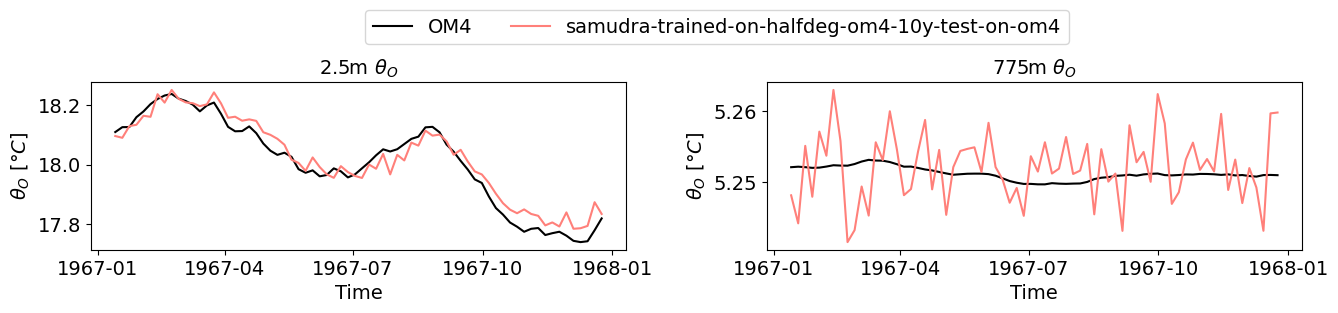

In [12]:
# Short Timeseries plots
shallow_levels = [2.5, 775]
num_shallow_levels = len(shallow_levels)

plt.rcParams.update({"font.size": 14})

num_plots = 0
for var in ["thetao"]:
    if "lev" in pred_dict[k]["ds_prediction"][var].coords:
        num_plots += num_shallow_levels  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 2  # Number of columns
rows = 1

fig, axes = plt.subplots(rows, cols, figsize=(16, 3))
axes = axes.flatten()  # Flatten the 2D array of axes for easy access

plot_idx = 0  # Initialize plot index to track subplot positions

# Loop over each variable to plot its time series
for v in ["thetao"]:
    if v == "zos":
        ax = axes[plot_idx]

        # Ground truth plot
        profile_groundtruth[v].plot(ax=ax, label=dataset_name, c="k")
        min_val = profile_groundtruth[v].min()
        max_val = profile_groundtruth[v].max()

        for i, k in enumerate(pred_dict.keys()):
            pred_dict[k]["profile_prediction"][v].plot(
                ax=ax, label=pred_dict[k]["name"], c=clist[i]
            )

        ax.set_ylim(min_val - 0.05, max_val + 0.05)
        ax.set_title(f"{v}")
        ax.set_xlabel("Time")
        ax.set_ylabel(var_list[v])

        plot_idx += 1

    else:
        for lev in shallow_levels:
            ax = axes[plot_idx]

            # Ground truth plot
            profile_groundtruth[v].sel(lev=lev).plot(ax=ax, label=dataset_name, c="k")
            mins, maxs = plt.ylim()

            for i, k in enumerate(pred_dict.keys()):
                pred_dict[k]["profile_prediction"][v].sel(lev=lev).plot(
                    ax=ax, label=pred_dict[k]["name"], c=clist[i]
                )

            # Adjust y-axis limits
            if v == "thetao":
                if lev > 100:
                    # ax.set_ylim(mins - 0.02, maxs + 0.02)
                    pass
                # else:
                #     ax.set_ylim(mins - 0.25, maxs + 0.25)
            elif v == "so":
                ax.set_ylim(mins - 0.2, maxs + 0.2)

            ax.set_title(f"{lev}m" + r" $\theta_O$", fontsize=14)
            ax.set_xlabel("Time")
            ax.set_ylabel(r"$\theta_O$ [$\degree C$]")

            plot_idx += 1
            if plot_idx >= rows * cols:
                break

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])

# Create a single legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.455, 0.9), ncols=3)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# Save the figure
output_file = os.path.join(
    timeseries_path, "temperature_timeseries_grid_shallow_both.png"
)
plt.savefig(output_file, bbox_inches="tight", dpi=600)

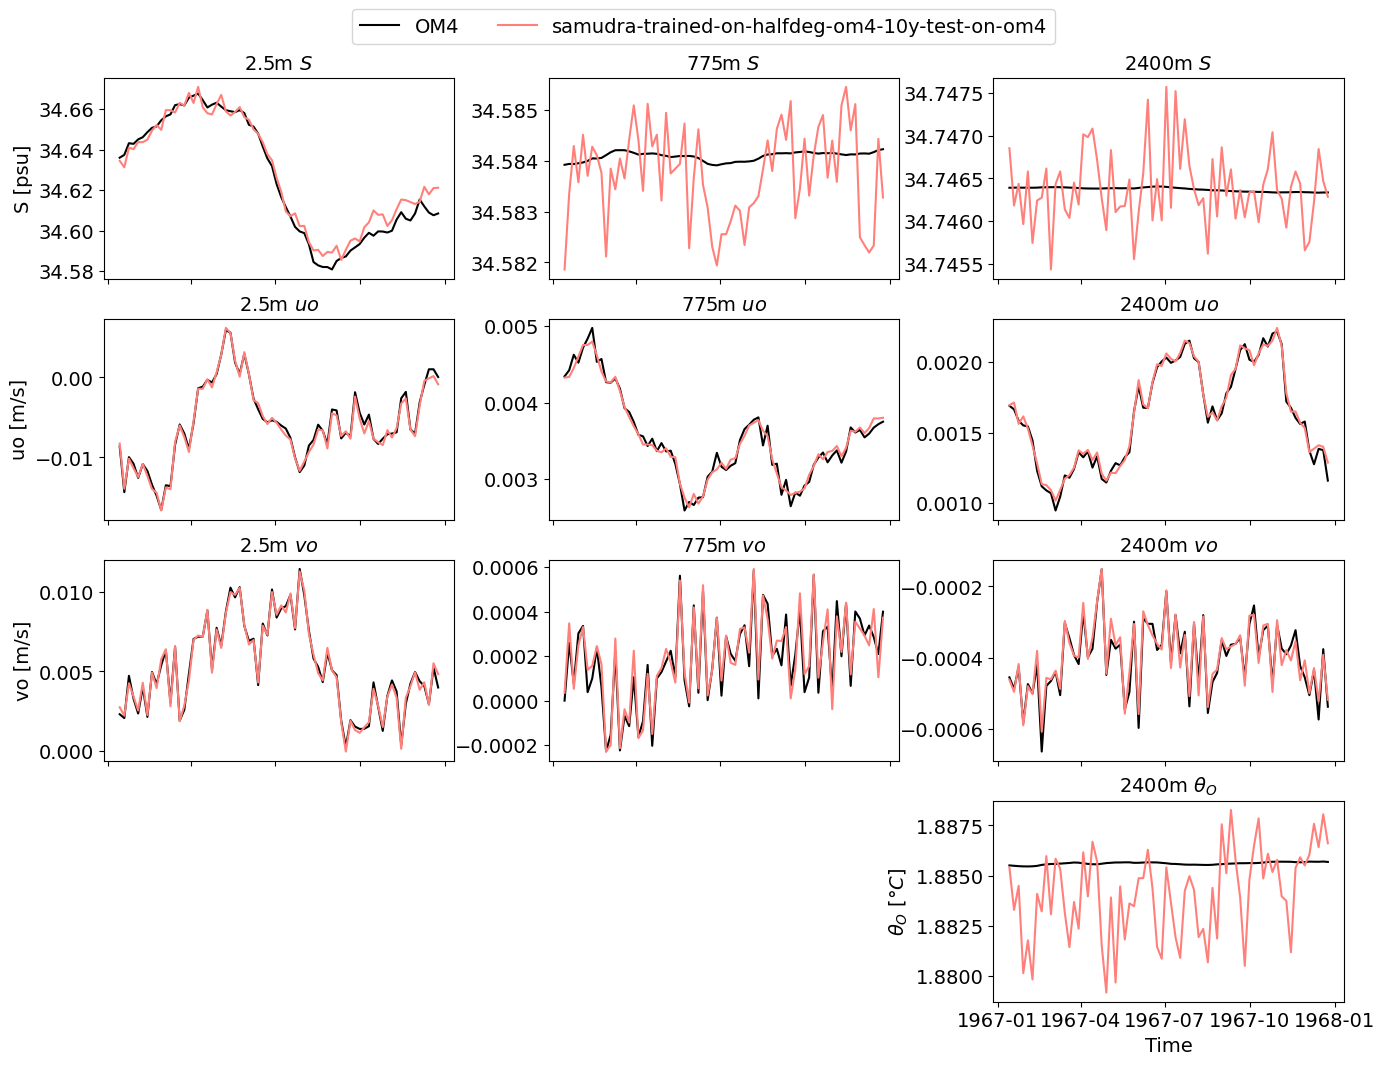

In [13]:
shallow_levels = [2.5, 775, 2400]  # Define shallow depth levels
num_shallow_levels = len(shallow_levels)

plt.rcParams.update({"font.size": 14})

variables = [
    "so",
    "uo",
    "vo",
    "thetao",
]  # List of variables for rows: salinity, zonal velocity, meridional velocity
cols = len(shallow_levels)  # Number of columns corresponds to shallow levels
rows = len(variables)  # One row per variable

fig, axes = plt.subplots(
    rows, cols, figsize=(16, 12), gridspec_kw={"wspace": 0.27, "hspace": 0.2}
)  # Adjust figure size for more rows
axes = axes.reshape(rows, cols)  # Reshape axes for easy access by row and column

# Define labels for each variable
var_labels = {
    "so": "S [psu]",
    "uo": "uo [m/s]",
    "vo": "vo [m/s]",
    "thetao": r"$\theta_O$ [$\degree C$]",
}

# Loop over each variable and plot profiles for each shallow level
for row_idx, var in enumerate(variables):
    for col_idx, lev in enumerate(shallow_levels):
        ax = axes[row_idx, col_idx]  # Access subplot by row and column

        if var == "thetao" and (lev == 2.5 or lev == 775):
            fig.delaxes(ax)
            continue

        # Ground truth plot for each variable at the specified level
        profile_groundtruth[var].sel(lev=lev).plot(ax=ax, label=dataset_name, c="k")
        mins, maxs = ax.get_ylim()

        for i, k in enumerate(pred_dict.keys()):
            if var in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][var].sel(lev=lev).plot(
                    ax=ax, label=pred_dict[k]["name"], c=clist[i]
                )

        # Adjust y-axis limits based on the variable

        if var == "thetao":
            # if lev > 2000:
            #     ax.set_ylim(mins - 0.01, maxs + 0.01)
            # elif lev > 100:
            #     ax.set_ylim(mins - 0.01, maxs + 0.01)
            # else:
            #     ax.set_ylim(mins - 0.25, maxs + 0.25)
            ax.set_title(f"{lev}m " + r"$\theta_O$", fontsize=14)
        elif var == "so":  # Salinity
            # if lev > 2000:
            #     ax.set_ylim(mins - 0.001, maxs + 0.001)
            # elif lev > 100:
            #     ax.set_ylim(mins - 0.004, maxs + 0.004)
            # else:
            #     ax.set_ylim(mins - 0.1, maxs + 0.1)
            ax.set_title(f"{lev}m $S$", fontsize=14)
            handles, labels = ax.get_legend_handles_labels()
        if v in pred_dict[k]["ls"]:
            if var == "uo":  # Zonal velocity
                # if lev > 2000:
                #     ax.set_ylim(mins - 0.0003, maxs + 0.0003)
                # elif lev > 100:
                #     ax.set_ylim(mins - 0.0005, maxs + 0.0005)
                # else:
                #     ax.set_ylim(mins - 0.005, maxs + 0.005)
                ax.set_title(f"{lev}m $uo$", fontsize=14)
            elif var == "vo":  # Meridional velocity
                # if lev > 2000:
                #     ax.set_ylim(mins - 0.0002, maxs + 0.0002)
                # elif lev > 100:
                #     ax.set_ylim(mins - 0.0004, maxs + 0.0004)
                # else:
                #     ax.set_ylim(mins - 0.005, maxs + 0.005)
                ax.set_title(f"{lev}m $vo$", fontsize=14)

        # ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

        # Set y-axis label only on the leftmost column
        if col_idx == 0 or var == "thetao":
            ax.set_ylabel(var_labels[var])  # Set y-axis label based on variable
        else:
            ax.set_ylabel("")
            # ax.set_yticklabels([])  # Hide y-axis tick labels for other columns

        # Set x-axis label and ticks only on the bottommost row
        if row_idx == rows - 1:
            ax.set_xlabel("Time")
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])


# Adjust layout to avoid overlap and place the legend outside the plot
# fig.tight_layout(rect=[0, 0, 0.85, 0.96])

# Create a single legend for all plots
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.90), ncols=3)

# Save the figure with an updated filename
output_file = os.path.join(timeseries_path, "timeseries_grid_shallow_all_vars.png")
plt.savefig(output_file, bbox_inches="tight", dpi=600)
# plt.show()
# plt.close(fig)

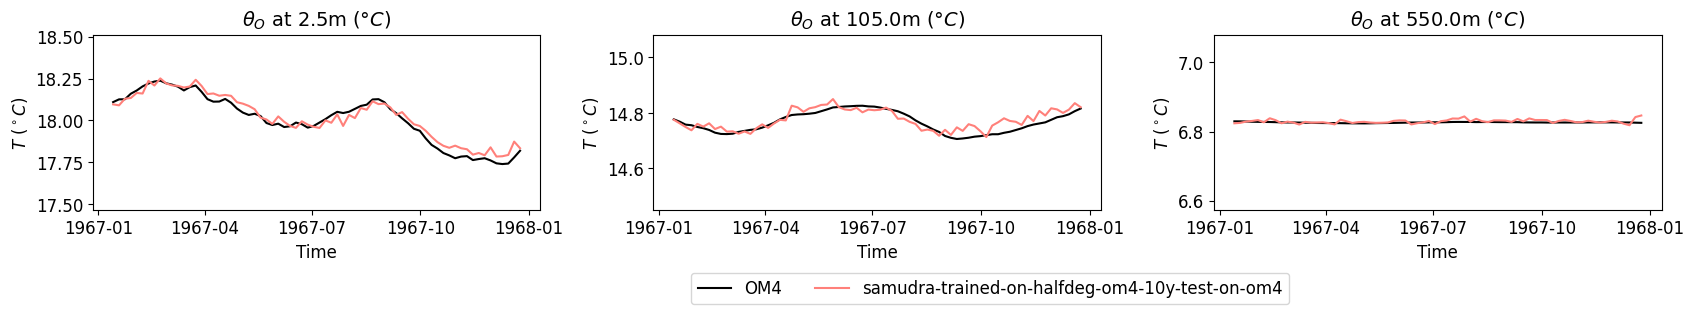

In [14]:
shallow_levels = [2.5, 105, 550]

num_shallow_levels = len(shallow_levels)

plt.rcParams.update({"font.size": 12})
num_plots = 0
for var in ["thetao"]:
    if "lev" in pred_dict[k]["ds_prediction"][var].coords:
        num_plots += num_shallow_levels  # One plot per level
    else:
        num_plots += 1  # One plot for scalar variables

# Set grid size dynamically based on the number of required plots
cols = 3  # Number of columns
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()  # Flatten the 2D array of axes for easy access

plot_idx = 0  # Initialize plot index to track subplot positions

# Loop over each variable to plot its time series
for v in ["thetao"]:
    if v == "zos":
        # Handle 'zos' separately (no levels)
        ax = axes[plot_idx]
        profile_groundtruth[v].plot(ax=ax, label=dataset_name, c="k")

        for i, k in enumerate(pred_dict.keys()):
            if v in pred_dict[k]["ls"]:
                pred_dict[k]["profile_prediction"][v].plot(
                    ax=ax, label=pred_dict[k]["name"], c=clist[i]
                )

        # Adjust y-axis limits and formatting
        min_val, max_val = ax.get_ylim()
        ax.set_ylim(min_val - 0.05, max_val + 0.05)
        ax.set_title(f"{v}", fontsize=14)
        ax.set_xlabel("Time")
        ax.set_ylabel(var_list[v])

        plot_idx += 1  # Move to the next subplot

    else:
        # For other variables, loop over each level
        for lev in shallow_levels:
            ax = axes[plot_idx]
            profile_groundtruth[v].sel(lev=lev).plot(ax=ax, label=dataset_name, c="k")

            min_val, max_val = ax.get_ylim()
            for i, k in enumerate(pred_dict.keys()):
                if v in pred_dict[k]["ls"]:
                    pred_dict[k]["profile_prediction"][v].sel(lev=lev).plot(
                        ax=ax, label=pred_dict[k]["name"], c=clist[i]
                    )

            # Adjust y-axis limits for specific variables
            if v == "thetao":
                ax.set_ylim(min_val - 0.25, max_val + 0.25)
            elif v == "so":
                ax.set_ylim(min_val - 0.2, max_val + 0.2)

            ax.set_title(
                r"$\theta_O$"
                + f" at {pred_dict[k]['profile_prediction'][v].sel(lev=lev).lev.item()}m"
                + r" ($\degree C$)",
                fontsize=14,
            )
            ax.set_xlabel("Time")
            ax.set_ylabel(var_list[v])

            plot_idx += 1  # Move to the next subplot

            if plot_idx >= rows * cols:
                break  # Stop if the grid is full

# Adjust layout to avoid overlap and place the legend outside the plot
fig.tight_layout(rect=[0, 0, 0.85, 0.96])  # Leave space on the right for the legend

# Create a single legend for all plots
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    ncols=3,
    bbox_to_anchor=(0.34, -0.03),
    fontsize=12,
)

# fig.suptitle("Time Series Plots", fontsize=24)

# Remove any empty subplots
for idx in range(num_plots, len(axes)):
    fig.delaxes(axes[idx])

# Save the figure
output_file = os.path.join(timeseries_path, "temp_timeseries_grid_shallow_skipped.png")
plt.savefig(output_file, bbox_inches="tight", dpi=600)

samudra-trained-on-halfdeg-om4-10y-test-on-om4: -0.004422372952256488
OHC:  -0.0066563236795869245


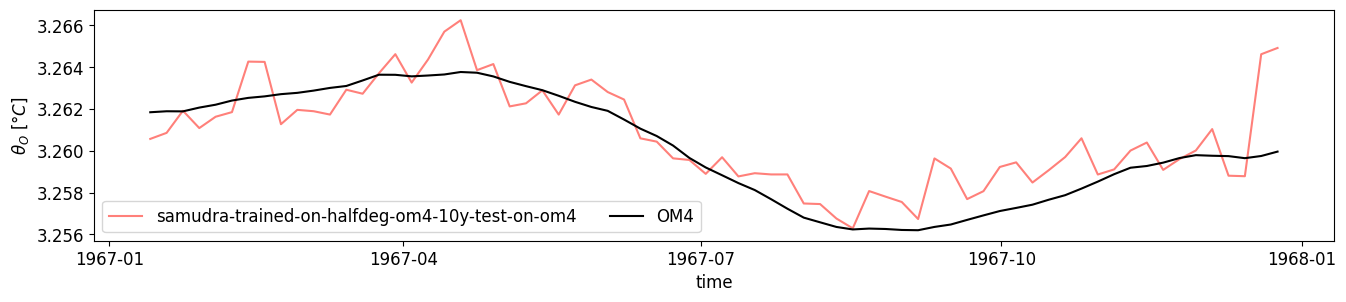

In [15]:
var = "thetao"
Days_to_Eq = 0

plt.rcdefaults()
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(
    1, 1, figsize=(16, 3), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

thetao = (
    ds_groundtruth["thetao"]
    .weighted(ds_groundtruth["areacello"] * ds_groundtruth["dz"])
    .mean(["x", "y", "lev"])
)
thetao = thetao.rename(r"$\theta_O$")
thetao = thetao.assign_attrs(units=r"$\degree C$")

for i, k in enumerate(pred_dict.keys()):
    thetao_pred = (
        pred_dict[k]["ds_prediction"][var]
        .weighted(ds_groundtruth["areacello"] * ds_groundtruth["dz"])
        .mean(["x", "y", "lev"])
    )
    thetao_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
    coeffs_ = np.polyfit(
        np.arange(thetao_pred[Days_to_Eq:].size), thetao_pred[Days_to_Eq:], 1
    )
    print(f"{pred_dict[k]['name']}: {coeffs_[0] * 73}")

thetao.plot(ax=ax, label=dataset_name, c="k")
coeffs_OHC_ground_trend = np.polyfit(
    np.arange(thetao[Days_to_Eq:].size), thetao[Days_to_Eq:], 1
)
print("OHC: ", coeffs_OHC_ground_trend[0] * 73)

ax.legend(ncol=3)
ax.set_title("")
# ax.set_ylim([3.230, 3.245])
plt.savefig(
    os.path.join(timeseries_path, f"Global_Thetao_Timeseries"),
    bbox_inches="tight",
    dpi=600,
)
# plt.show()

samudra-trained-on-halfdeg-om4-10y-test-on-om4: 0.00012117607763052686
OHC:  -0.00019588063750484275


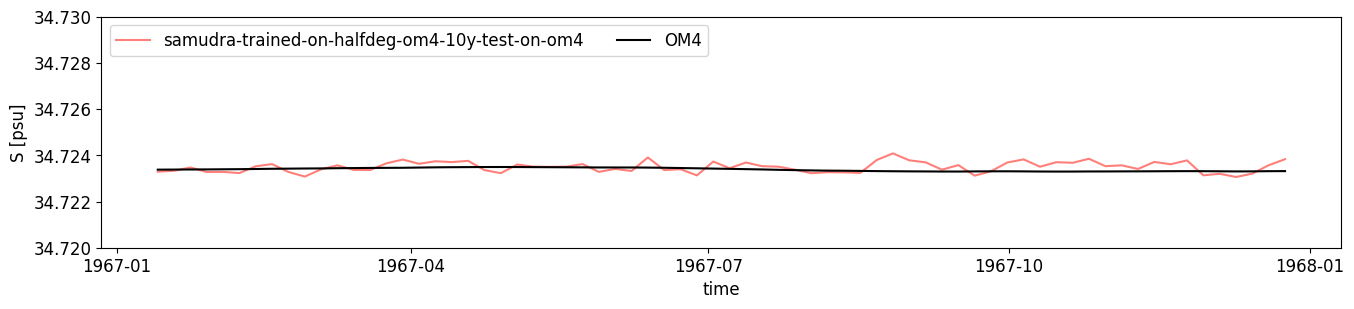

In [16]:
var = "so"

plt.rcdefaults()
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(
    1, 1, figsize=(16, 3), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

salinity = (
    ds_groundtruth["so"]
    .weighted(ds_groundtruth["areacello"] * ds_groundtruth["dz"])
    .mean(["x", "y", "lev"])
)
salinity = salinity.rename("S")
salinity = salinity.assign_attrs(units="psu")

for i, k in enumerate(pred_dict.keys()):
    salinity_pred = (
        pred_dict[k]["ds_prediction"][var]
        .weighted(ds_groundtruth["areacello"] * ds_groundtruth["dz"])
        .mean(["x", "y", "lev"])
    )
    salinity_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
    coeffs_ = np.polyfit(
        np.arange(salinity_pred[Days_to_Eq:].size), salinity_pred[Days_to_Eq:], 1
    )
    print(f"{pred_dict[k]['name']}: {coeffs_[0] * 73}")

salinity.plot(ax=ax, label=dataset_name, c="k")
coeffs_salinity_ground_trend = np.polyfit(
    np.arange(salinity[Days_to_Eq:].size), salinity[Days_to_Eq:], 1
)
print("OHC: ", coeffs_salinity_ground_trend[0] * 73)

ax.legend(ncol=3, loc="upper left")
# ax.set_ylim([34.723, 34.728])
ax.set_ylim([34.72, 34.73])
ax.set_title("")
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
plt.savefig(
    os.path.join(timeseries_path, f"Global_Salinity_Timeseries"),
    bbox_inches="tight",
    dpi=600,
)

### OHC Plots

#### OHC Timeseries

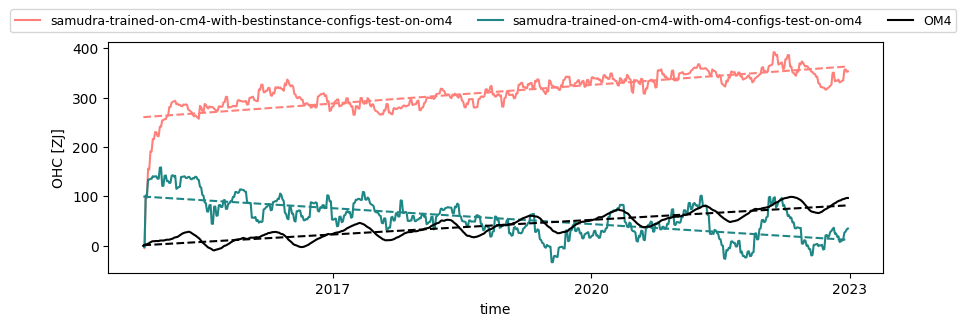

In [86]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
f = open(os.path.join(output_path, "compare_info.txt"), "a")

plt.rcdefaults()
fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)
plt.rcParams.update({"font.size": 9})

OHC = ((data["thetao"] * c_p * rho_0) * data["areacello"] * data["dz"]).sum(
    ["x", "y", "lev"]
) / 1e21
OHC = OHC - OHC.isel(time=0)
OHC = OHC.rename("OHC")
OHC = OHC.assign_attrs(units="ZJ")

for i, k in enumerate(pred_dict.keys()):
    OHC_pred = (
        (pred_dict[k]["ds_prediction"]["thetao"] * c_p * rho_0)
        * pred_dict[k]["ds_prediction"]["areacello"]
        * pred_dict[k]["ds_prediction"]["dz"]
    ).sum(["x", "y", "lev"]) / 1e21
    OHC_pred = OHC_pred - OHC_pred.isel(time=0)
    OHC_pred = OHC_pred.rename("OHC")
    OHC_pred = OHC_pred.assign_attrs(units="ZJ")
    OHC_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
    coeffs_OHC_pred_trend = np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
    (pos,) = ax.plot(
        OHC_pred.time.data,
        np.arange(OHC_pred.size) * coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],
        c=clist[i],
        ls="--",
    )
    # ax[0].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}',
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
    #          fontsize=9, color=clist[i])
    f.write(f"\nOHC {pred_dict[k]['name']} Trend Slope : {coeffs_OHC_pred_trend[0]}")
    pred_dict[k]["OHC_slope"] = coeffs_OHC_pred_trend[0]

OHC.plot(ax=ax, label=dataset_name, c="k")
coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
(pos,) = ax.plot(
    OHC.time.data,
    np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
    c="k",
    ls="--",
)
# ax[0].annotate(f'{coeffs_OHC_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nOHC GT Trend Slope : {coeffs_OHC_trend[0]}")
GT_ohc_slope = coeffs_OHC_trend[0]
# ax.legend()
ax.set_title("")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.89), ncols=3)

f.close()
plt.savefig(os.path.join(ohc_path, "OHC_ref0_noanomaly"), bbox_inches="tight", dpi=600)

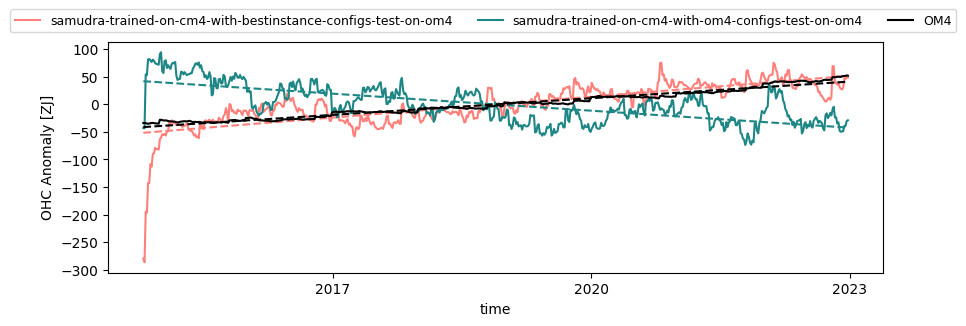

In [87]:
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
f = open(os.path.join(output_path, "compare_info.txt"), "a")

plt.rcdefaults()
fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)
plt.rcParams.update({"font.size": 9})

OHC = ((data["thetao"] * c_p * rho_0) * data["areacello"] * data["dz"]).sum(
    ["x", "y", "lev"]
) / 1e21
OHC = remove_climatology(OHC)
OHC = OHC.rename("OHC Anomaly")
OHC = OHC.assign_attrs(units="ZJ")

for i, k in enumerate(pred_dict.keys()):
    OHC_pred = (
        (pred_dict[k]["ds_prediction"]["thetao"] * c_p * rho_0)
        * pred_dict[k]["ds_prediction"]["areacello"]
        * pred_dict[k]["ds_prediction"]["dz"]
    ).sum(["x", "y", "lev"]) / 1e21
    OHC_pred = remove_climatology(OHC_pred)
    OHC_pred = OHC_pred.rename("OHC Anomaly")
    OHC_pred = OHC_pred.assign_attrs(units="ZJ")
    OHC_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
    coeffs_OHC_pred_trend = np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
    (pos,) = ax.plot(
        OHC_pred.time.data,
        np.arange(OHC_pred.size) * coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],
        c=clist[i],
        ls="--",
    )
    # ax[0].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}',
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
    #          fontsize=9, color=clist[i])
    f.write(f"\nOHC {pred_dict[k]['name']} Trend Slope : {coeffs_OHC_pred_trend[0]}")
    pred_dict[k]["OHC_slope"] = coeffs_OHC_pred_trend[0]

OHC.plot(ax=ax, label=dataset_name, c="k")
coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
(pos,) = ax.plot(
    OHC.time.data,
    np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
    c="k",
    ls="--",
)
# ax[0].annotate(f'{coeffs_OHC_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nOHC GT Trend Slope : {coeffs_OHC_trend[0]}")
GT_ohc_slope = coeffs_OHC_trend[0]
# ax.legend()
ax.set_title("")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.89), ncols=3)

f.close()
plt.savefig(os.path.join(ohc_path, "OHC"), bbox_inches="tight", dpi=600)

#### Depth wise OHC

upper_trend_truth:  9.42740736188766
samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4  upper_trend_pred:  -4.152112456083328
samudra-trained-on-cm4-with-om4-configs-test-on-om4  upper_trend_pred:  -8.326059877113687
mid_trend_truth:  0.6724772658765307
samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4  mid_trend_pred:  5.163597432837597
samudra-trained-on-cm4-with-om4-configs-test-on-om4  mid_trend_pred:  0.7465815469306272
deep_trend_truth:  -0.028759345482237804
samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4  deep_trend_pred:  11.596865389825885
samudra-trained-on-cm4-with-om4-configs-test-on-om4  deep_trend_pred:  -2.7162586031287472


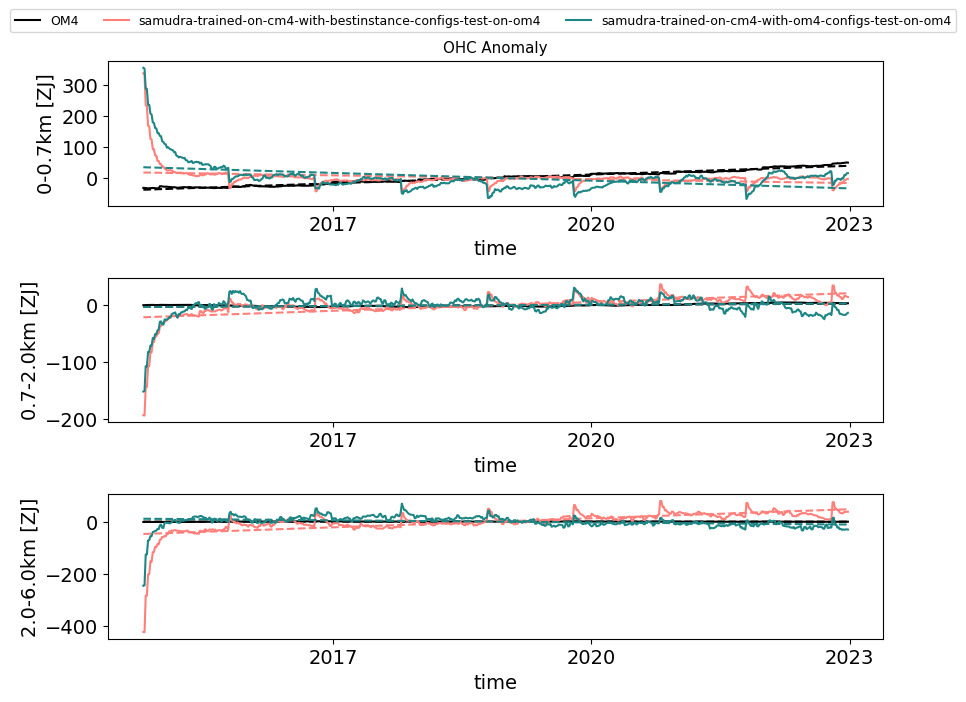

In [88]:
# %matplotlib inline
plt.rcParams.update({"font.size": 14})

Days_to_Eq = 0
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
fig, ax = plt.subplots(
    3, 1, figsize=(10, 7.5), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)
plt.rcParams.update({"font.size": 9})

f = open(os.path.join(output_path, "compare_info.txt"), "a")


# Upper - GT
OHC_truth_upper = (
    (data["thetao"].sel(lev=slice(0, 700)) * c_p * rho_0)
    * data["areacello"]
    * data["dz"]
).sum(["x", "y", "lev"]) / 1e21

OHC_truth_upper = remove_climatology(OHC_truth_upper)
OHC_truth_upper.plot(ax=ax[0], label=dataset_name, c="k")
coeffs_OHC_ground_trend = np.polyfit(
    np.arange(OHC_truth_upper[Days_to_Eq:].size), OHC_truth_upper[Days_to_Eq:], 1
)
(pos,) = ax[0].plot(
    OHC_truth_upper[Days_to_Eq:].time.data,
    np.arange(OHC_truth_upper[Days_to_Eq:].size) * coeffs_OHC_ground_trend[0]
    + coeffs_OHC_ground_trend[1],
    c="k",
    ls="--",
)
# ax[0].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nUpper - GT Trend Slope : {coeffs_OHC_ground_trend[0]}")
GT_upper = coeffs_OHC_ground_trend[0]
upper_trend_truth = coeffs_OHC_ground_trend[0] * 73
print("upper_trend_truth: ", upper_trend_truth)

# Upper - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_upper"] = (
        (pred_dict[k]["ds_prediction"]["thetao"].sel(lev=slice(0, 700)) * c_p * rho_0)
        * pred_dict[k]["ds_prediction"]["areacello"]
        * pred_dict[k]["ds_prediction"]["dz"]
    ).sum(["x", "y", "lev"]) / 1e21

    pred_dict[k]["OHC_pred_upper"] = remove_climatology(pred_dict[k]["OHC_pred_upper"])
    pred_dict[k]["OHC_pred_upper"] = pred_dict[k]["OHC_pred_upper"].rename("0-0.7km")
    pred_dict[k]["OHC_pred_upper"] = pred_dict[k]["OHC_pred_upper"].assign_attrs(
        units="ZJ"
    )
    pred_dict[k]["coeffs_OHC_pred_trend_upper"] = np.polyfit(
        np.arange(pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].size),
        pred_dict[k]["OHC_pred_upper"][Days_to_Eq:],
        1,
    )
    pred_dict[k]["OHC_pred_upper"].plot(
        ax=ax[0], label=pred_dict[k]["name"], c=clist[i]
    )
    (pos,) = ax[0].plot(
        pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].time.data,
        np.arange(pred_dict[k]["OHC_pred_upper"][Days_to_Eq:].size)
        * pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]
        + pred_dict[k]["coeffs_OHC_pred_trend_upper"][1],
        c=clist[i],
        ls="--",
    )
    # ax[0].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]:.2e}',
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
    #          fontsize=9, color=clist[i])
    f.write(
        f"\nUpper - {pred_dict[k]['name']} Trend Slope : {pred_dict[k]['coeffs_OHC_pred_trend_upper'][0]}"
    )
    pred_dict[k]["upper_trend_pred"] = (
        pred_dict[k]["coeffs_OHC_pred_trend_upper"][0] * 73
    )
    print(pred_dict[k]["name"], " upper_trend_pred: ", pred_dict[k]["upper_trend_pred"])
    pred_dict[k]["total_trend_pred"] = pred_dict[k]["upper_trend_pred"]

# ax[0].legend()
ax[0].set_title("OHC Anomaly")


# Middle - GT
OHC_truth_mid = (
    (data["thetao"].sel(lev=slice(700, 2000)) * c_p * rho_0)
    * data["areacello"]
    * data["dz"]
).sum(["x", "y", "lev"]) / 1e21

In [ ]:
OHC_truth_mid = remove_climatology(OHC_truth_mid)
OHC_truth_mid.plot(ax=ax[1], label=dataset_name, c="k")
coeffs_OHC_ground_trend = np.polyfit(
    np.arange(OHC_truth_mid[Days_to_Eq:].size), OHC_truth_mid[Days_to_Eq:], 1
)
(pos,) = ax[1].plot(
    OHC_truth_mid[Days_to_Eq:].time.data,
    np.arange(OHC_truth_mid[Days_to_Eq:].size) * coeffs_OHC_ground_trend[0]
    + coeffs_OHC_ground_trend[1],
    c="k",
    ls="--",
)
# ax[1].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nMiddle - GT Trend Slope : {coeffs_OHC_ground_trend[0]}")
GT_mid = coeffs_OHC_ground_trend[0]
mid_trend_truth = coeffs_OHC_ground_trend[0] * 73
print("mid_trend_truth: ", mid_trend_truth)

# Middle - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_mid"] = (
        (
            pred_dict[k]["ds_prediction"]["thetao"].sel(lev=slice(700, 2000))
            * c_p
            * rho_0
        )
        * pred_dict[k]["ds_prediction"]["areacello"]
        * pred_dict[k]["ds_prediction"]["dz"]
    ).sum(["x", "y", "lev"]) / 1e21

    pred_dict[k]["OHC_pred_mid"] = remove_climatology(pred_dict[k]["OHC_pred_mid"])
    pred_dict[k]["OHC_pred_mid"] = pred_dict[k]["OHC_pred_mid"].rename("0.7-2.0km")
    pred_dict[k]["OHC_pred_mid"] = pred_dict[k]["OHC_pred_mid"].assign_attrs(units="ZJ")
    pred_dict[k]["coeffs_OHC_pred_trend_mid"] = np.polyfit(
        np.arange(pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].size),
        pred_dict[k]["OHC_pred_mid"][Days_to_Eq:],
        1,
    )
    pred_dict[k]["OHC_pred_mid"].plot(ax=ax[1], label=pred_dict[k]["name"], c=clist[i])
    (pos,) = ax[1].plot(
        pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].time.data,
        np.arange(pred_dict[k]["OHC_pred_mid"][Days_to_Eq:].size)
        * pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]
        + pred_dict[k]["coeffs_OHC_pred_trend_mid"][1],
        c=clist[i],
        ls="--",
    )
    # ax[1].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_mid"][0]:.2e}',
    #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
    #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
    #          fontsize=9, color=clist[i])
    f.write(
        f"\nMiddle - {pred_dict[k]['name']} Trend Slope : {pred_dict[k]['coeffs_OHC_pred_trend_mid'][0]}"
    )
    pred_dict[k]["mid_trend_pred"] = pred_dict[k]["coeffs_OHC_pred_trend_mid"][0] * 73
    print(pred_dict[k]["name"], " mid_trend_pred: ", pred_dict[k]["mid_trend_pred"])
    pred_dict[k]["total_trend_pred"] += pred_dict[k]["mid_trend_pred"]

# ax[1].legend()
ax[1].set_title("")

# Deep - GT
OHC_truth_deep = (
    (data["thetao"].sel(lev=slice(2000, None)) * c_p * rho_0)
    * data["areacello"]
    * data["dz"]
).sum(["x", "y", "lev"]) / 1e21

OHC_truth_deep = remove_climatology(OHC_truth_deep)
OHC_truth_deep.plot(ax=ax[2], label=dataset_name, c="k")
coeffs_OHC_ground_trend = np.polyfit(
    np.arange(OHC_truth_deep[Days_to_Eq:].size), OHC_truth_deep[Days_to_Eq:], 1
)
(pos,) = ax[2].plot(
    OHC_truth_deep[Days_to_Eq:].time.data,
    np.arange(OHC_truth_deep[Days_to_Eq:].size) * coeffs_OHC_ground_trend[0]
    + coeffs_OHC_ground_trend[1],
    c="k",
    ls="--",
)
# ax[2].annotate(f'{coeffs_OHC_ground_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nDeep - GT Trend Slope : {coeffs_OHC_ground_trend[0]}")
GT_deep = coeffs_OHC_ground_trend[0]
deep_trend_truth = coeffs_OHC_ground_trend[0] * 73
print("deep_trend_truth: ", deep_trend_truth)

# Deep - Pred
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["OHC_pred_deep"] = (
        (
            pred_dict[k]["ds_prediction"]["thetao"].sel(lev=slice(2000, None))
            * c_p
            * rho_0
        )
        * pred_dict[k]["ds_prediction"]["areacello"]
        * pred_dict[k]["ds_prediction"]["dz"]
    ).sum(["x", "y", "lev"]) / 1e21

    pred_dict[k]["OHC_pred_deep"] = remove_climatology(pred_dict[k]["OHC_pred_deep"])
    pred_dict[k]["OHC_pred_deep"] = pred_dict[k]["OHC_pred_deep"].rename("2.0-6.0km")
    pred_dict[k]["OHC_pred_deep"] = pred_dict[k]["OHC_pred_deep"].assign_attrs(
        units="ZJ"
    )
    pred_dict[k]["coeffs_OHC_pred_trend_deep"] = np.polyfit(
        np.arange(pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].size),
        pred_dict[k]["OHC_pred_deep"][Days_to_Eq:],
        1,
    )
    pred_dict[k]["OHC_pred_deep"].plot(ax=ax[2], label=pred_dict[k]["name"], c=clist[i])
    (pos,) = ax[2].plot(
        pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].time.data,
        np.arange(pred_dict[k]["OHC_pred_deep"][Days_to_Eq:].size)
        * pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]
        + pred_dict[k]["coeffs_OHC_pred_trend_deep"][1],
        c=clist[i],
        ls="--",
    )
    # ax[2].annotate(f'{pred_dict[k]["coeffs_OHC_pred_trend_deep"][0]:.2e}',
    #      xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
    #      xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
    #      fontsize=9, color=clist[i])
    f.write(
        f"\nDeep - {pred_dict[k]['name']} Trend Slope : {pred_dict[k]['coeffs_OHC_pred_trend_deep'][0]}"
    )

    pred_dict[k]["deep_trend_pred"] = pred_dict[k]["coeffs_OHC_pred_trend_deep"][0] * 73
    print(pred_dict[k]["name"], " deep_trend_pred: ", pred_dict[k]["deep_trend_pred"])
    pred_dict[k]["total_trend_pred"] += pred_dict[k]["deep_trend_pred"]

# ax[2].legend()
ax[2].set_title("")
total_trend_truth = upper_trend_truth + mid_trend_truth + deep_trend_truth

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.91), ncols=3)

f.write(
    f"\nGT Trend Ratio (Upper, Mid, Deep): {upper_trend_truth / total_trend_truth:.2f}, {mid_trend_truth / total_trend_truth:.2f}, {deep_trend_truth / total_trend_truth:.2f}"
)
for k in pred_dict.keys():
    f.write(
        f"\n{pred_dict[k]['name']} Trend Ratio (Upper, Mid, Deep): {pred_dict[k]['upper_trend_pred'] / pred_dict[k]['total_trend_pred']:.2f}, {pred_dict[k]['mid_trend_pred'] / pred_dict[k]['total_trend_pred']:.2f}, {pred_dict[k]['deep_trend_pred'] / pred_dict[k]['total_trend_pred']:.2f}"
    )
# ax[0].annotate(f'OHC portion of trend (truth, pred): ({upper_trend_truth/total_trend_truth:.2f}, {upper_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
# ax[1].annotate(f'OHC portion of trend (truth, pred): ({mid_trend_truth/total_trend_truth:.2f}, {mid_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
# ax[2].annotate(f'OHC portion of trend (truth, pred): ({deep_trend_truth/total_trend_truth:.2f}, {deep_trend_pred/total_trend_pred:.2f})',xy = (.2,.95), xycoords='axes fraction',
#             horizontalalignment='left', verticalalignment='top')
f.write("\n")
f.close()

plt.savefig(
    os.path.join(ohc_path, "OHC_Timeseries_depths"), bbox_inches="tight", dpi=600
)

In [89]:
pd_data = []
pd_data.append(
    {"Model": dataset_name, "Upper": GT_upper, "Middle": GT_mid, "Deep": GT_deep}
)

for k in pred_dict.keys():
    pd_data.append(
        {
            "Model": pred_dict[k]["name"],
            "Upper": pred_dict[k]["coeffs_OHC_pred_trend_upper"][0],
            "Upper Slope Ratio": pred_dict[k]["coeffs_OHC_pred_trend_upper"][0]
            / GT_upper,
            "Middle": pred_dict[k]["coeffs_OHC_pred_trend_mid"][0],
            "Middle Slope Ratio": pred_dict[k]["coeffs_OHC_pred_trend_mid"][0] / GT_mid,
            "Deep": pred_dict[k]["coeffs_OHC_pred_trend_deep"][0],
            "Deep Slope Ratio": pred_dict[k]["coeffs_OHC_pred_trend_deep"][0] / GT_deep,
        }
    )

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(ohc_path, "depthwise_ohc_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

#### Basin OHC

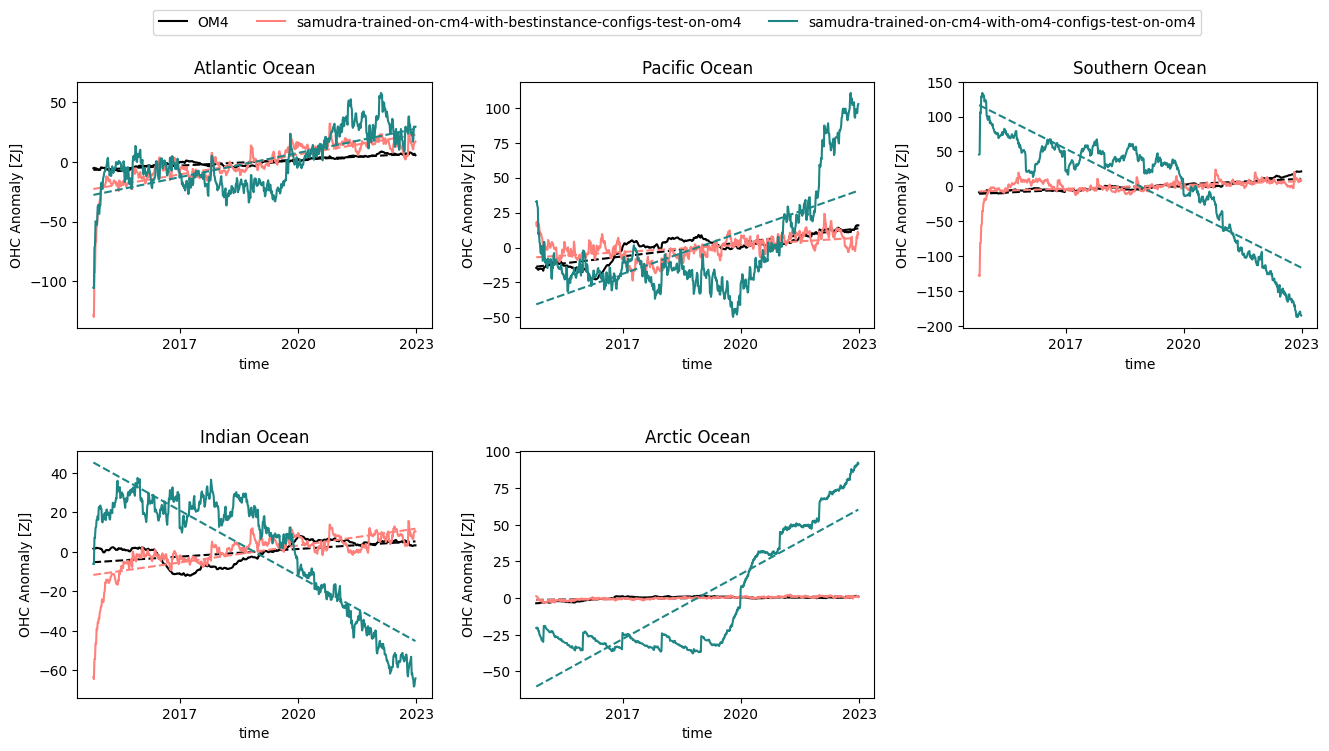

In [90]:
# Compute Basin Heat Content Time Series

f = open(os.path.join(output_path, "compare_info.txt"), "a")

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

plt.rcParams.update({"font.size": 10})
fig, ax = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "height_ratios": [1, 1],
        "wspace": 0.25,
        "hspace": 0.5,
    },
)

ax_flat = ax.flatten()

GT_regionwise_ohc = {}
GT_regionwise_ohc["Model"] = dataset_name
for j, k in enumerate(pred_dict.keys()):
    pred_dict[k]["regionwise_ohc"] = {}

for i, var in enumerate(list(basin_masks.keys())):
    OHC = (
        (data["thetao"] * c_p * rho_0 * basin_masks[var])
        * data["areacello"]
        * data["dz"]
    ).sum(["x", "y", "lev"]) / 1e21

    OHC = remove_climatology(OHC)
    OHC = OHC.rename("OHC Anomaly")
    OHC = OHC.assign_attrs(units="ZJ")
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    OHC.plot(ax=ax_flat[i], label=dataset_name, c="k")
    (pos,) = ax_flat[i].plot(
        OHC.time.data,
        np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
        c="k",
        ls="--",
    )
    # ax_flat[i].annotate(f'{coeffs_OHC_trend[0]:.2e}',
    #          xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
    #          xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
    #          fontsize=9, color='k')
    f.write(f"\nOHC {var} GT Trend Slope : {coeffs_OHC_trend[0]}")
    GT_regionwise_ohc[var] = coeffs_OHC_trend[0]
    for j, k in enumerate(pred_dict.keys()):
        OHC_pred = (
            (pred_dict[k]["ds_prediction"]["thetao"] * c_p * rho_0 * basin_masks[var])
            * pred_dict[k]["ds_prediction"]["areacello"]
            * pred_dict[k]["ds_prediction"]["dz"]
        ).sum(["x", "y", "lev"]) / 1e21

        OHC_pred = remove_climatology(OHC_pred)
        OHC_pred = OHC_pred.rename("OHC Anomaly")
        OHC_pred = OHC_pred.assign_attrs(units="ZJ")
        coeffs_OHC_pred_trend = np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
        OHC_pred.plot(ax=ax_flat[i], label=pred_dict[k]["name"], c=clist[j])
        (pos,) = ax_flat[i].plot(
            OHC_pred.time.data,
            np.arange(OHC_pred.size) * coeffs_OHC_pred_trend[0]
            + coeffs_OHC_pred_trend[1],
            c=clist[j],
            ls="--",
        )
        # ax_flat[i].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}',
        #      xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
        #      xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
        #      fontsize=9, color=clist[j])
        f.write(
            f"\nOHC {var} {pred_dict[k]['name']} Trend Slope : {coeffs_OHC_pred_trend[0]}"
        )
        pred_dict[k]["regionwise_ohc"][var] = coeffs_OHC_pred_trend[0]

    ax_flat[i].set_title(var + " Ocean")

fig.delaxes(ax_flat[5])
handles, labels = ax_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.93), ncols=3)

f.write("\n")
f.close()
# plt.show()
plt.savefig(os.path.join(ohc_path, "OHC_Basin"), bbox_inches="tight", dpi=600)

In [91]:
pd_data = []
pd_data.append(GT_regionwise_ohc)


for k in pred_dict.keys():
    d = {}
    d["Model"] = pred_dict[k]["name"]
    for var in basin_masks.keys():
        d[var] = pred_dict[k]["regionwise_ohc"][var]
        d[var + " Slope Ratio"] = (
            pred_dict[k]["regionwise_ohc"][var] / GT_regionwise_ohc[var]
        )
    pd_data.append(d)

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(ohc_path, "regionwise_ohc_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

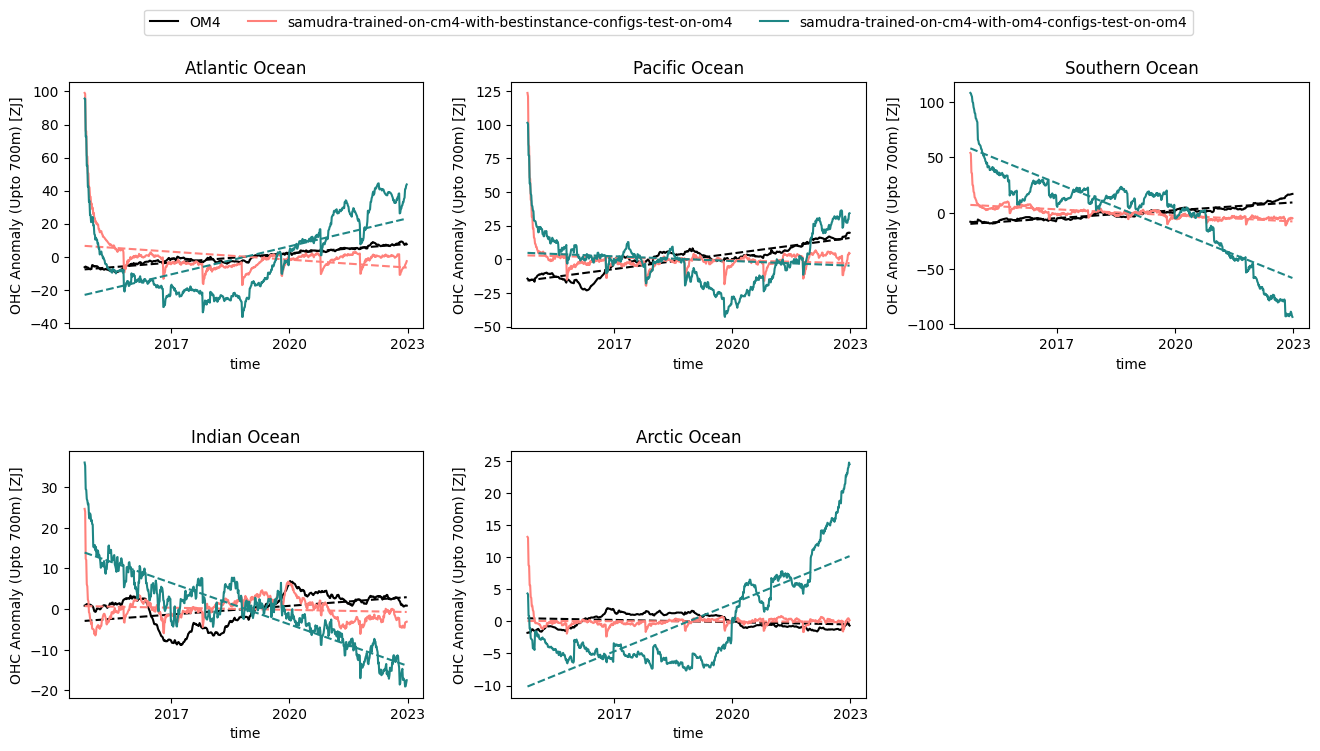

In [92]:
# Compute Basin Heat Content Time Series

f = open(os.path.join(output_path, "compare_info.txt"), "a")

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
max_level = 700

plt.rcParams.update({"font.size": 10})
fig, ax = plt.subplots(
    2,
    3,
    figsize=(16, 8),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "height_ratios": [1, 1],
        "wspace": 0.25,
        "hspace": 0.5,
    },
)

ax_flat = ax.flatten()

GT_regionwise_ohc = {}
GT_regionwise_ohc["Model"] = dataset_name
for j, k in enumerate(pred_dict.keys()):
    pred_dict[k]["regionwise_ohc"] = {}

for i, var in enumerate(list(basin_masks.keys())):
    OHC = (
        (
            data["thetao"].sel(lev=slice(None, max_level))
            * c_p
            * rho_0
            * basin_masks[var]
        )
        * data["areacello"]
        * data["dz"]
    ).sum(["x", "y", "lev"]) / 1e21

    OHC = remove_climatology(OHC)
    OHC = OHC.rename(f"OHC Anomaly (Upto {max_level}m)")
    OHC = OHC.assign_attrs(units="ZJ")
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    OHC.plot(ax=ax_flat[i], label=dataset_name, c="k")
    (pos,) = ax_flat[i].plot(
        OHC.time.data,
        np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
        c="k",
        ls="--",
    )
    # ax_flat[i].annotate(f'{coeffs_OHC_trend[0]:.2e}',
    #          xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
    #          xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
    #          fontsize=9, color='k')
    f.write(f"\nOHC {var} GT Trend Slope : {coeffs_OHC_trend[0]}")
    GT_regionwise_ohc[var] = coeffs_OHC_trend[0]
    for j, k in enumerate(pred_dict.keys()):
        OHC_pred = (
            (
                pred_dict[k]["ds_prediction"]["thetao"].sel(lev=slice(None, max_level))
                * c_p
                * rho_0
                * basin_masks[var]
            )
            * pred_dict[k]["ds_prediction"]["areacello"]
            * pred_dict[k]["ds_prediction"]["dz"]
        ).sum(["x", "y", "lev"]) / 1e21

        OHC_pred = remove_climatology(OHC_pred)
        OHC_pred = OHC_pred.rename(f"OHC Anomaly (Upto {max_level}m)")
        OHC_pred = OHC_pred.assign_attrs(units="ZJ")
        coeffs_OHC_pred_trend = np.polyfit(np.arange(OHC_pred.size), OHC_pred, 1)
        OHC_pred.plot(ax=ax_flat[i], label=pred_dict[k]["name"], c=clist[j])
        (pos,) = ax_flat[i].plot(
            OHC_pred.time.data,
            np.arange(OHC_pred.size) * coeffs_OHC_pred_trend[0]
            + coeffs_OHC_pred_trend[1],
            c=clist[j],
            ls="--",
        )
        # ax_flat[i].annotate(f'{coeffs_OHC_pred_trend[0]:.2e}',
        #      xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
        #      xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
        #      fontsize=9, color=clist[j])
        f.write(
            f"\nOHC {var} {pred_dict[k]['name']} Trend Slope : {coeffs_OHC_pred_trend[0]}"
        )
        pred_dict[k]["regionwise_ohc"][var] = coeffs_OHC_pred_trend[0]

    ax_flat[i].set_title(var + " Ocean")

fig.delaxes(ax_flat[5])
handles, labels = ax_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.93), ncol=3)

f.write("\n")
f.close()
# plt.show()
plt.savefig(
    os.path.join(ohc_path, f"OHC_Basin_upto_{max_level}m"), bbox_inches="tight", dpi=600
)

### Temperature Plots

In [93]:
def get_basin_datasets(ds):
    da_temp = ds * basin_masks["Atlantic"]
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    At = da_temp_int_x.where(~section_mask)

    da_temp = ds * basin_masks["Indian"]
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    In = da_temp_int_x.where(~section_mask)

    da_temp = ds * basin_masks["Pacific"]
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    Pa = da_temp_int_x.where(~section_mask)

    da_temp = ds * basin_masks["Southern"]
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    So = da_temp_int_x.where(~section_mask)

    da_temp = ds * basin_masks["Arctic"]
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    Ar = da_temp_int_x.where(~section_mask)

    da_temp = ds
    section_mask = np.isnan(da_temp).all("x")
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x"])
    Gl = da_temp_int_x.where(~section_mask)

    return [At, In, Pa, So, Ar, Gl], [
        "Atlantic",
        "Indian",
        "Pacific",
        "Southern",
        "Arctic",
        "Global",
    ]

In [94]:
def ocean_temperature_profile(datasets, titles, plot_title, vmin=-0.3, vmax=0.3):
    fig, axs = plt.subplots(
        2,
        3,
        figsize=(16, 6),
        gridspec_kw={
            "width_ratios": [0.05] * 3,
            "height_ratios": [0.05] * 2,
            "wspace": 0.01,
            "hspace": 0.5,
        },
        dpi=300,
    )
    fig.suptitle(plot_title, fontsize=15, fontweight="bold", y=0.95)

    ax = axs.flatten()

    for i, (data, title) in enumerate(zip(datasets, titles)):
        data = data.rename(r"$\theta_O$").assign_attrs(units=r"$\degree C$")
        data["y"] = data.y.assign_attrs(long_name="Latitude", units=r"$\degree$")
        data["lev"] = data.lev.assign_attrs(long_name="depth", units="m")

        im = data.plot(ax=ax[i], cmap="bwr", vmin=vmin, vmax=vmax, add_colorbar=False)
        ax[i].invert_yaxis()
        linear_piecewise_scale(1000, 5, ax=ax[i])
        ax[i].axhline(1000, color="0.5", ls="--")
        ax[i].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
        ax[i].set_xticks([-60, -30, 0, 30, 60])
        ax[i].set_xticklabels(
            [r"$60^\circ S$", r"$30^\circ S$", "0", r"$30^\circ N$", r"$60^\circ N$"]
        )
        ax[i].set_title(title, fontsize=14)
        ax[i].set_box_aspect(0.7)

    cbar = fig.colorbar(im, ax=ax[:], orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label(r"$\theta_O$ [$\degree C$]")
    # plt.show()
    plt.savefig(os.path.join(temp_path, plot_title), bbox_inches="tight", dpi=600)

In [95]:
data_thetao_ano = remove_climatology(data.thetao)
pred_thetao_ano = remove_climatology(pred_dict["pred_1"]["ds_prediction"]["thetao"])

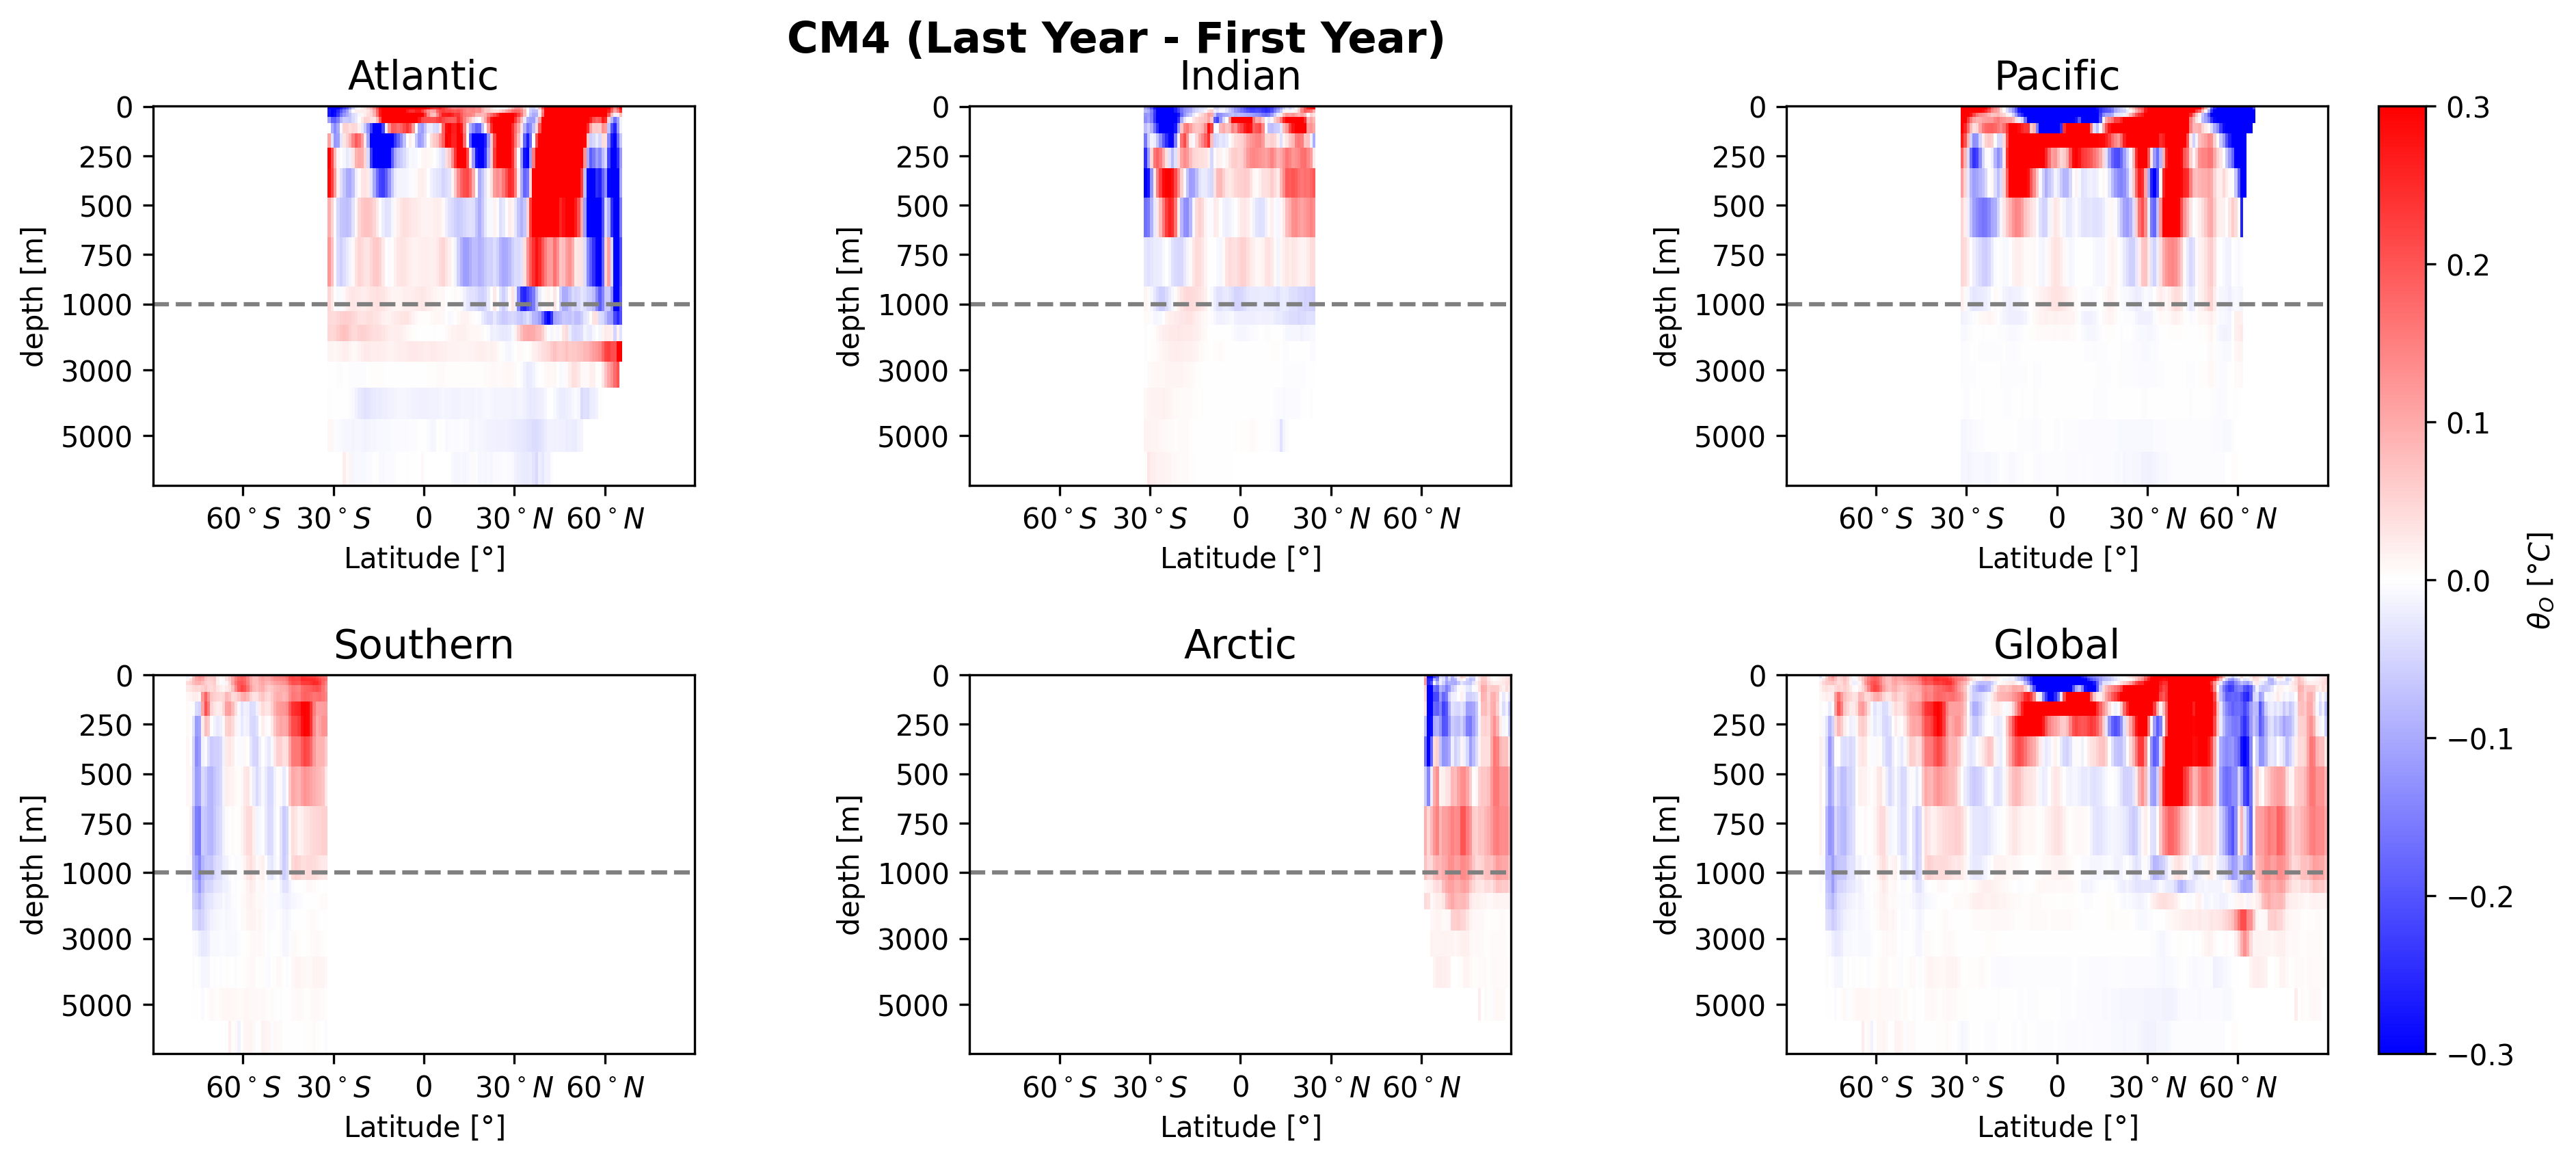

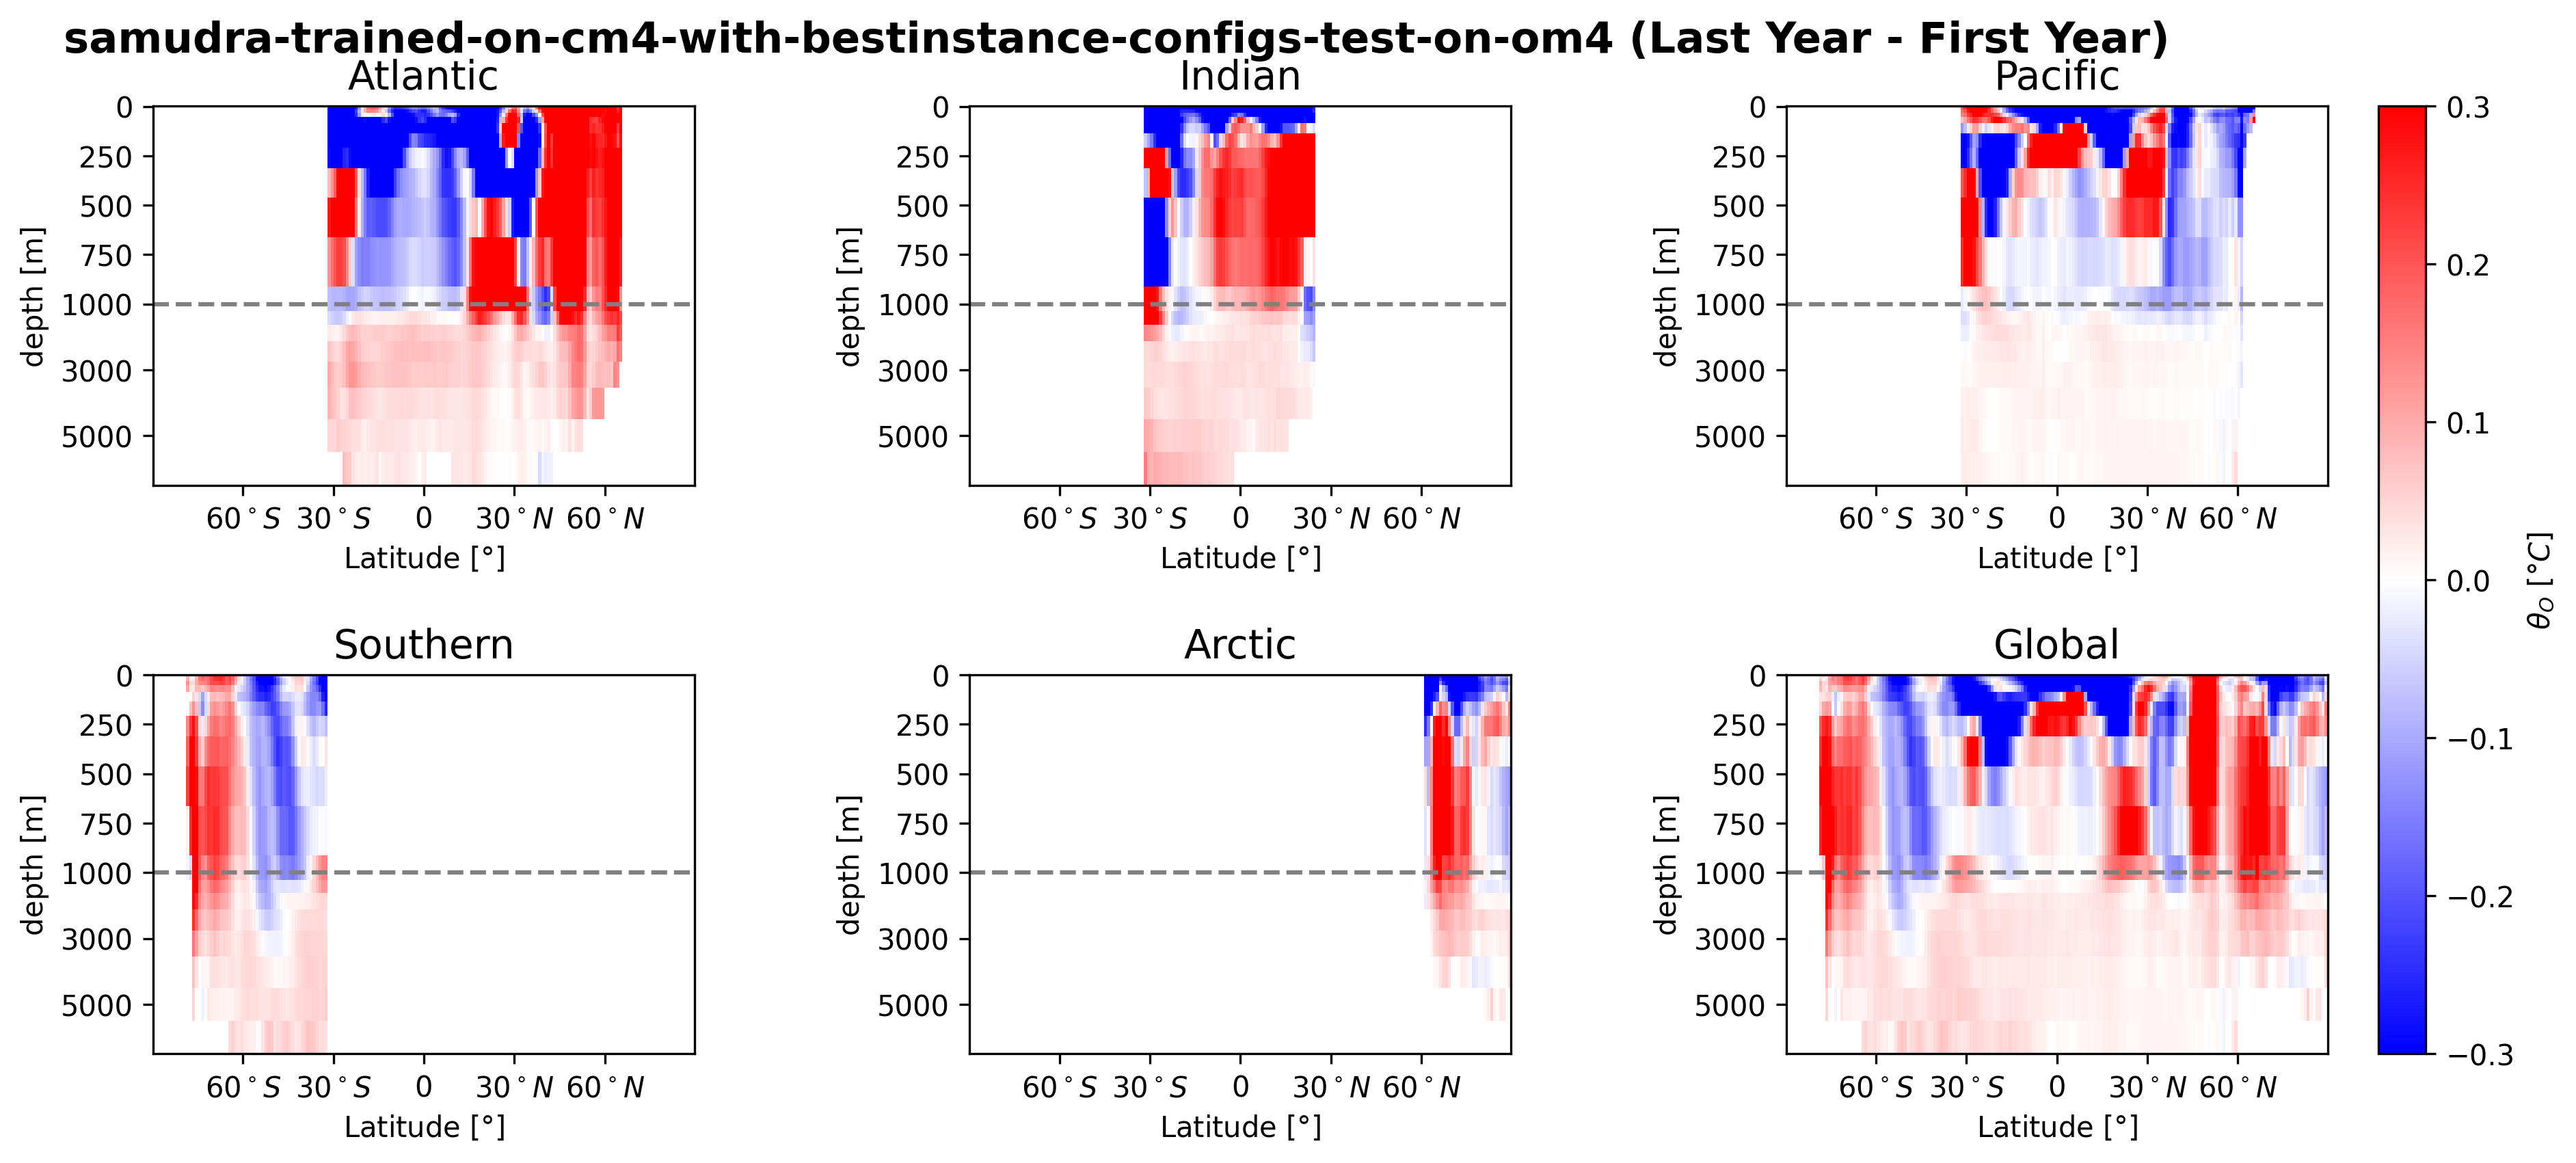

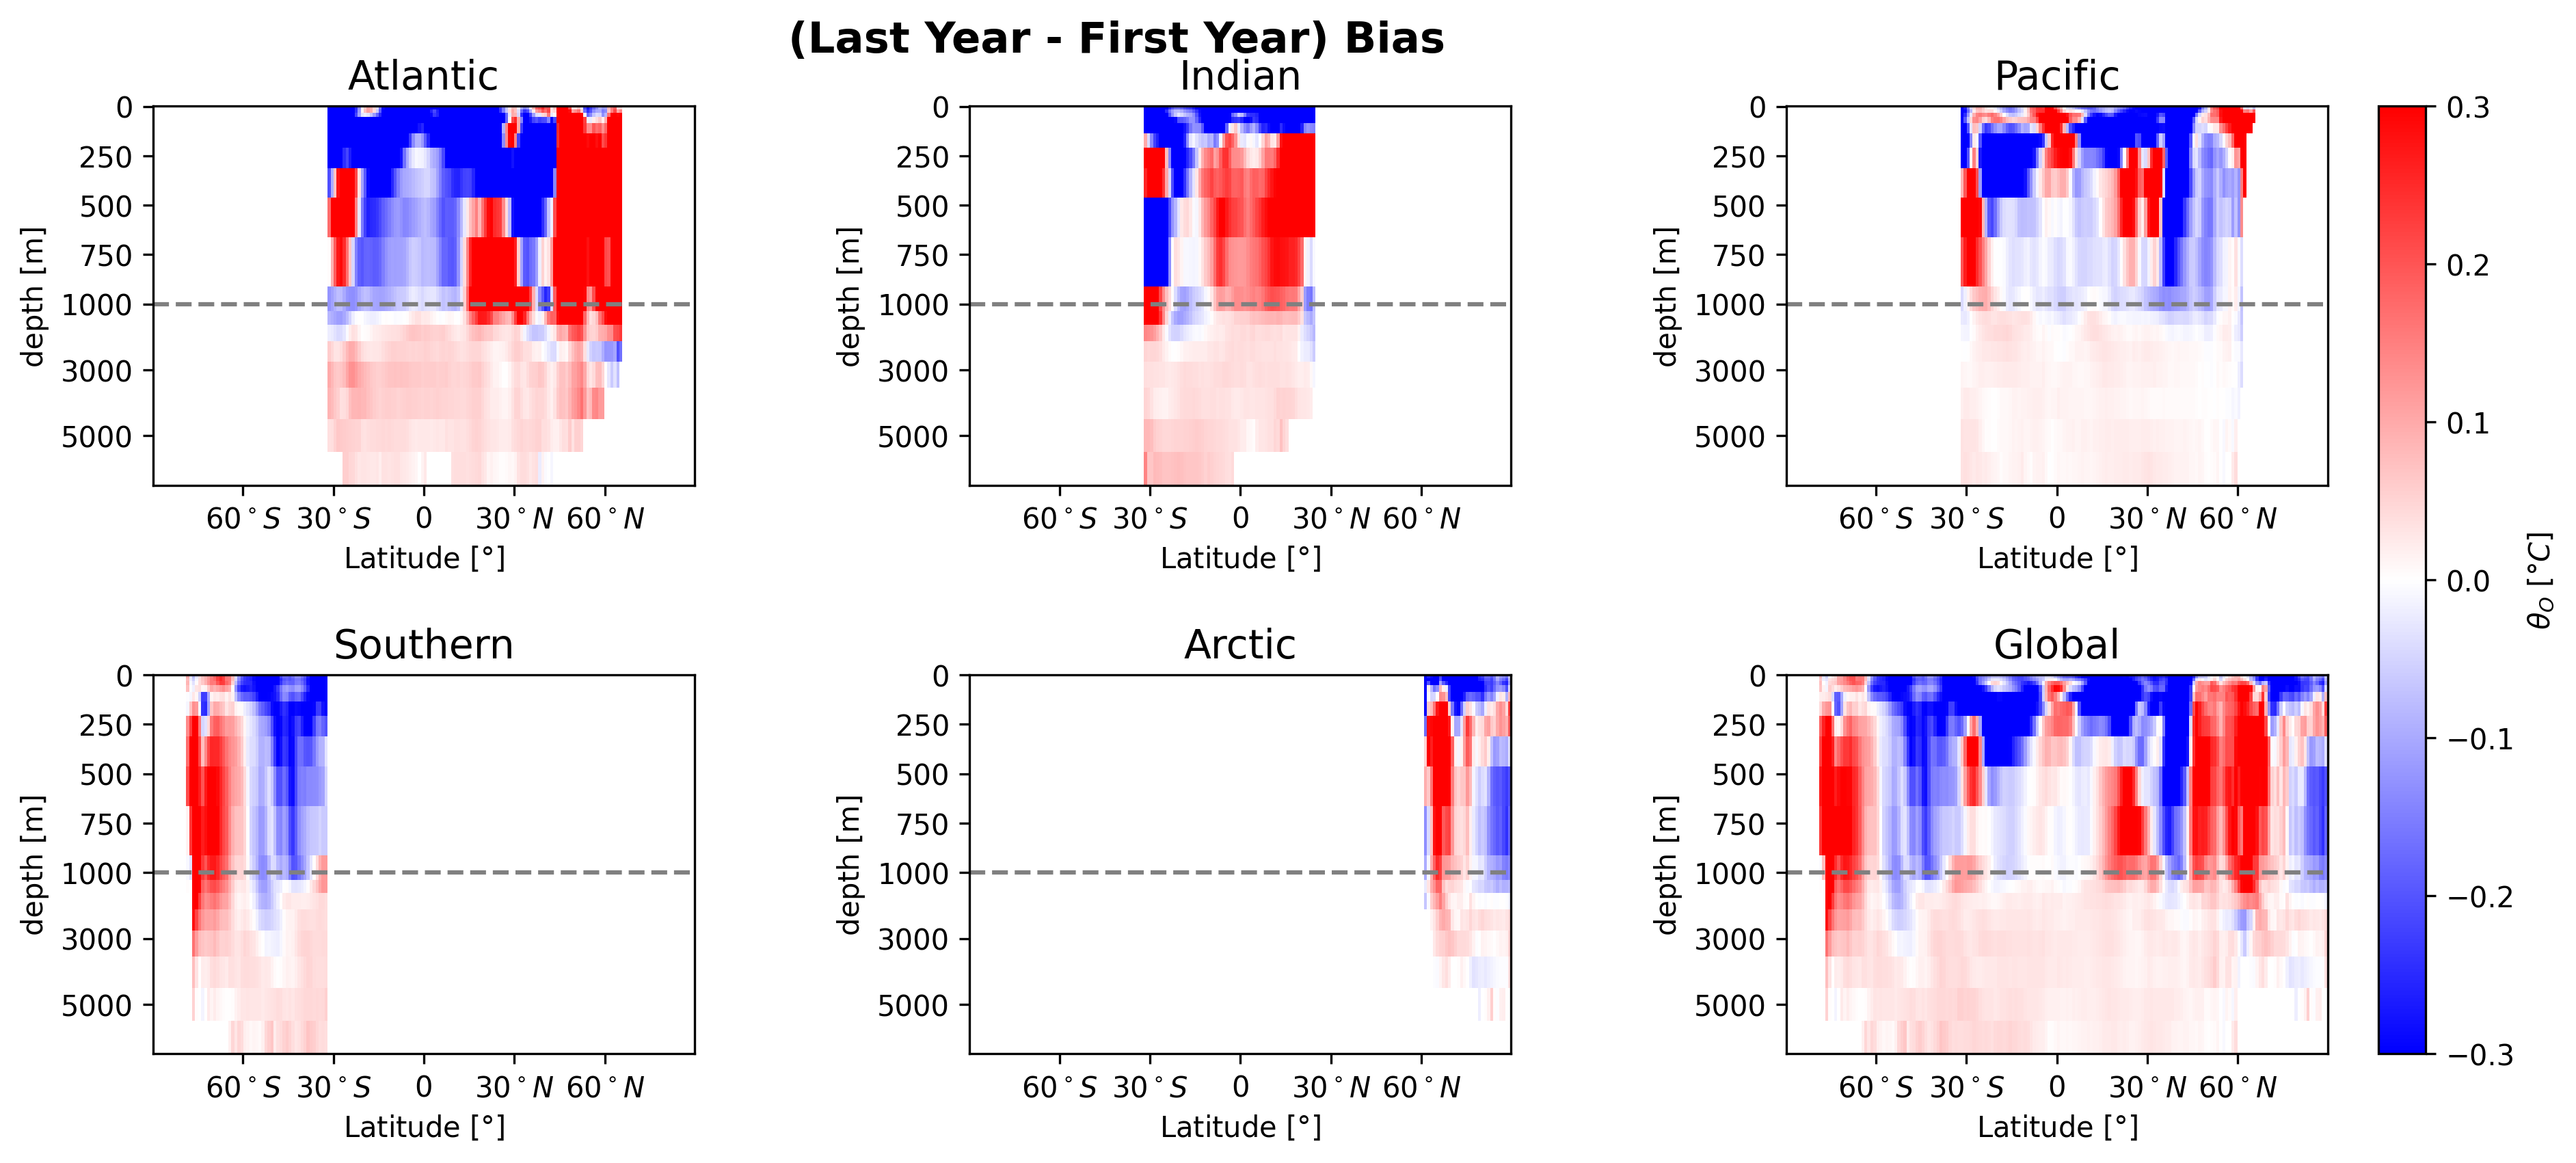

In [96]:
# Full time mean and bias [Last year - First year]
CM4_lastyear_change = data_thetao_ano.isel(time=slice(-73, None)).mean(
    dim="time"
) - data_thetao_ano.isel(time=slice(0, 73)).mean(dim="time")
datasets, titles = get_basin_datasets(CM4_lastyear_change)
plot_title = "CM4 (Last Year - First Year)"
ocean_temperature_profile(datasets, titles, plot_title)

pred_lastyear_change = pred_thetao_ano.isel(time=slice(-73, None)).mean(
    dim="time"
) - pred_thetao_ano.isel(time=slice(0, 73)).mean(dim="time")
datasets, titles = get_basin_datasets(pred_lastyear_change)
plot_title = f"{pred_dict['pred_1']['name']} (Last Year - First Year)"
ocean_temperature_profile(datasets, titles, plot_title)

bias_lastyear_change = pred_lastyear_change - CM4_lastyear_change
datasets, titles = get_basin_datasets(bias_lastyear_change)
plot_title = f"(Last Year - First Year) Bias"
ocean_temperature_profile(datasets, titles, plot_title)

### Salinity Plots

-1.1008732044220084e+16


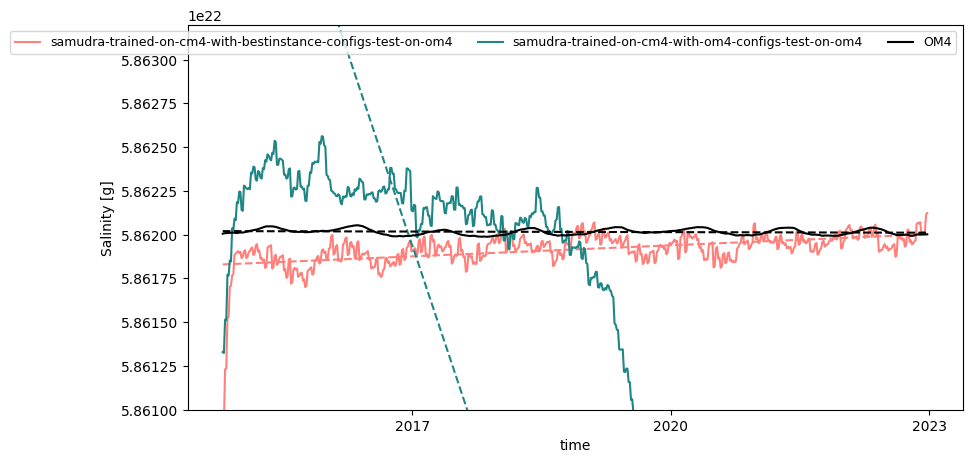

In [97]:
rho_0 = 1025  # kg/m^3
f = open(os.path.join(output_path, "compare_info.txt"), "a")

plt.rcdefaults()
fig, ax = plt.subplots(1, 1, figsize=(10, 5))  # Single axis for salinity plot
plt.rcParams.update({"font.size": 9})

salinity = ((data["so"] * rho_0) * data["areacello"] * data["dz"]).sum(
    ["x", "y", "lev"]
)
salinity = salinity.rename("Salinity")
salinity = salinity.assign_attrs(units="g")

for i, k in enumerate(pred_dict.keys()):
    if "so" in pred_dict[k]["ls"]:
        salinity_pred = (
            (pred_dict[k]["ds_prediction"]["so"] * rho_0)
            * pred_dict[k]["ds_prediction"]["areacello"]
            * pred_dict[k]["ds_prediction"]["dz"]
        ).sum(["x", "y", "lev"])
        salinity_pred = salinity_pred.rename("Salinity")
        salinity_pred = salinity_pred.assign_attrs(units="g")
        salinity_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
        coeffs_salinity_pred_trend = np.polyfit(
            np.arange(salinity_pred.size), salinity_pred, 1
        )
        (pos,) = ax.plot(
            salinity_pred.time.data,
            np.arange(salinity_pred.size) * coeffs_salinity_pred_trend[0]
            + coeffs_salinity_pred_trend[1],
            c=clist[i],
            ls="--",
        )
        f.write(
            f"\nSalinity {pred_dict[k]['name']} Trend Slope : {coeffs_salinity_pred_trend[0]}"
        )
        pred_dict[k]["salinity_slope"] = coeffs_salinity_pred_trend[0]

coeffs_salinity_trend = np.polyfit(np.arange(salinity.size), salinity, 1)
salinity.plot(ax=ax, label=dataset_name, c="k")
(pos,) = ax.plot(
    salinity.time.data,
    np.arange(salinity.size) * coeffs_salinity_trend[0] + coeffs_salinity_trend[1],
    c="k",
    ls="--",
)
f.write(f"\nSalinity GT Trend Slope : {coeffs_salinity_trend[0]}")
GT_salinity_slope = coeffs_salinity_trend[0]
ax.set_ylim([5.861e22, 5.8632e22])
ax.legend(ncol=3)
ax.set_title("")
f.write("\n")
f.close()

print(coeffs_salinity_trend[0] * 73)
plt.savefig(os.path.join(salinity_path, "Salinity"), bbox_inches="tight", dpi=600)

In [98]:
pd_data = []
pd_data.append(
    {
        "Model": dataset_name,
        "OHC": GT_ohc_slope,
        "Salinity": GT_salinity_slope,
    }
)

for k in pred_dict.keys():
    pd_data.append(
        {
            "Model": pred_dict[k]["name"],
            "OHC": pred_dict[k]["OHC_slope"],
            "OHC Slope Ratio": pred_dict[k]["OHC_slope"] / GT_ohc_slope,
            "Salinity": pred_dict[k]["salinity_slope"],
            "Salinity Slope Ratio": pred_dict[k]["salinity_slope"] / GT_salinity_slope,
        }
    )

# Create a DataFrame
df = pd.DataFrame(pd_data)

# Define the file path
file_path = os.path.join(output_path, "ohc_salinity_slopes_table.csv")

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

### Metrics

#### Deseasonalized Salinity Trend

-5.557493988306694e-06


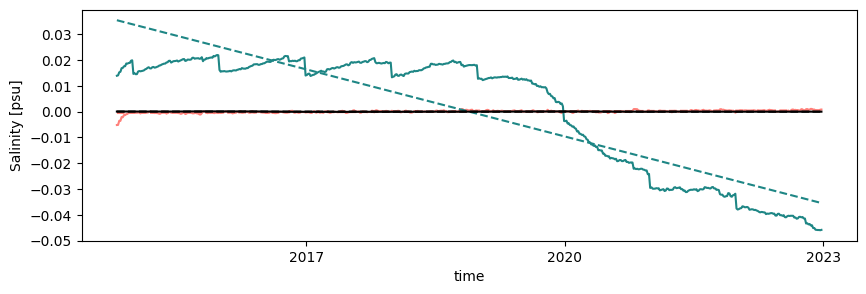

In [99]:
f = open(os.path.join(metrics_path, "salinity_deseasonalized_info.txt"), "a")

plt.rcdefaults()
fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)
plt.rcParams.update({"font.size": 9})

salinity = data["so"].weighted(data["areacello"] * data["dz"]).mean(["x", "y", "lev"])

salinity = remove_climatology(salinity)
salinity = salinity.rename("Salinity")
salinity = salinity.assign_attrs(units="psu")

for i, k in enumerate(pred_dict.keys()):
    if "so" in pred_dict[k]["ls"]:
        salinity_pred = (
            pred_dict[k]["ds_prediction"]["so"]
            .weighted(
                pred_dict[k]["ds_prediction"]["areacello"]
                * pred_dict[k]["ds_prediction"]["dz"]
            )
            .mean(["x", "y", "lev"])
        )
        salinity_pred = remove_climatology(salinity_pred)
        salinity_pred = salinity_pred.rename("Salinity")
        salinity_pred = salinity_pred.assign_attrs(units="psu")
        salinity_pred.plot(ax=ax, label=pred_dict[k]["name"], c=clist[i])
        coeffs_salinity_pred_trend = np.polyfit(
            np.arange(salinity_pred.size), salinity_pred, 1
        )
        (pos,) = ax.plot(
            salinity_pred.time.data,
            np.arange(salinity_pred.size) * coeffs_salinity_pred_trend[0]
            + coeffs_salinity_pred_trend[1],
            c=clist[i],
            ls="--",
        )
        # ax[1].annotate(f'{coeffs_salinity_pred_trend[0]:.2e}',
        #          xy=(pos.get_xdata()[-1], pos.get_ydata()[-1]),
        #          xytext=(pos.get_xdata()[-2], pos.get_ydata()[-2]),
        #          fontsize=9, color=clist[i])
        f.write(
            f"\nSalinity {pred_dict[k]['name']} Trend Slope : {coeffs_salinity_pred_trend[0]}"
        )
        pred_dict[k]["salinity_slope"] = coeffs_salinity_pred_trend[0]


coeffs_salinity_trend = np.polyfit(np.arange(salinity.size), salinity, 1)
salinity.plot(ax=ax, label=dataset_name, c="k")
(pos,) = ax.plot(
    salinity.time.data,
    np.arange(salinity.size) * coeffs_salinity_trend[0] + coeffs_salinity_trend[1],
    c="k",
    ls="--",
)
ax.set_title("")
# ax[1].annotate(f'{coeffs_salinity_trend[0]:.2e}',
#              xy=(pos.get_xdata()[0], pos.get_ydata()[0]),
#              xytext=(pos.get_xdata()[1], pos.get_ydata()[1]),
#              fontsize=9, color='k')
f.write(f"\nSalinity GT Trend Slope : {coeffs_salinity_trend[0]}")
GT_salinity_slope = coeffs_salinity_trend[0]
f.write("\n")
f.close()

print(coeffs_salinity_trend[0] * 73)
plt.savefig(
    os.path.join(salinity_path, "salinity_deseasonalized"), bbox_inches="tight", dpi=600
)

#### Thetao MAE

In [100]:
da_temp = data["thetao"]  # Directly use temperature variable
section_mask = np.isnan(da_temp).all("x").isel(time=0)
da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x", "time"])
temp_pred = da_temp_int_x.where(~section_mask)
GT_temp_pred = temp_pred

for j, (model_key, model_data) in enumerate(pred_dict.items(), start=1):
    da_temp = model_data["ds_prediction"]["thetao"]  # Use temperature variable
    section_mask = np.isnan(da_temp).all("x").isel(time=0)
    da_temp_int_x = da_temp.weighted(data["areacello"]).mean(["x", "time"])
    temp_pred = da_temp_int_x.where(~section_mask)
    pred_dict[model_key]["temp_profile"] = temp_pred

f = open(os.path.join(metrics_path, "thetao_mae_info.txt"), "a")

for i, key in enumerate(pred_dict):
    mae_key = np.abs((pred_dict[key]["temp_profile"] - GT_temp_pred)).mean().compute()
    f.write(f"\n Thetao {pred_dict[key]['name']} MAE : {mae_key.item()}")

f.close()

#### SST MAE

In [101]:
section_mask = np.isnan(data["thetao"]).isel(lev=0).isel(time=5)
SST_gt = data["thetao"].isel(lev=0).mean("time")
SST_gt = SST_gt.where(~section_mask)

for j, (model_key, model_data) in enumerate(pred_dict.items(), start=1):
    section_mask = (
        np.isnan(model_data["ds_prediction"]["thetao"]).isel(lev=0).isel(time=5)
    )
    SST_pred = model_data["ds_prediction"]["thetao"].isel(lev=0).mean("time")
    SST_pred = SST_pred.where(~section_mask)
    pred_dict[model_key]["sst"] = SST_pred

f = open(os.path.join(metrics_path, "sst_mae_info.txt"), "a")

for i, key in enumerate(pred_dict):
    mae_key = np.abs((pred_dict[key]["sst"] - SST_gt)).mean().compute()
    f.write(f"\n SST {pred_dict[key]['name']} MAE : {mae_key.item()}")

f.close()

#### Drake Passage / Atlantic MAE CORR

In [102]:
# # Drake Passage Full Depth
# day_start = -103
# window = 3
# regions = {
#     "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
#     "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
# }
# surface = False

# N_days = 100
# for i, region in enumerate(["Drake Passage", "Atlantic"]):
#     for k in pred_dict.keys():
#         pred_dict[k][region] = {"mae_mean": 0, "cor_mean": 0}
#         for j in range(N_days):

#             bounds = regions[region]
#             var = "thetao"
#             if surface:
#                 level_slice = slice(0, 1000)
#             else:
#                 level_slice = slice(None)

#             depth_slice = (
#                 data[var]
#                 .sel(x=bounds["lon"], method="nearest")
#                 .sel(y=bounds["lat_bnds"], lev=level_slice)
#                 .isel(time=slice(day_start, day_start + window))
#                 .mean("time")
#             )
#             wet = np.array(xr.where(np.isnan(depth_slice), False, True))
#             area = (
#                 data["areacello"]
#                 .sel(x=bounds["lon"], method="nearest")
#                 .sel(y=bounds["lat_bnds"])
#                 * data["dz"]
#             )
#             area = area.values.transpose()[wet]

#             depth_slice_pred = (
#                 pred_dict[k]["ds_prediction"][var]
#                 .sel(x=bounds["lon"], method="nearest")
#                 .sel(y=bounds["lat_bnds"], lev=level_slice)
#                 .isel(time=slice(day_start, day_start + window))
#                 .mean("time")
#             )
#             mae = np.abs(depth_slice_pred - depth_slice)
#             mae = (
#                 mae
#                 * data["areacello"]
#                 .sel(x=bounds["lon"], method="nearest")
#                 .sel(y=bounds["lat_bnds"])
#                 * data["dz"]
#             ).sum(["y", "lev"]) / (
#                 data["areacello"]
#                 .sel(x=bounds["lon"], method="nearest")
#                 .sel(y=bounds["lat_bnds"])
#                 * data["dz"]
#             ).sum()
#             mae = mae.assign_attrs(long_name="MAE", units=r"${^oC}$")
#             pred_dict[k][region]["mae_mean"] += 1 / N_days * mae.values
#             cor = (
#                 area
#                 * depth_slice_pred.values[wet].flatten()
#                 * depth_slice.values[wet].flatten()
#             ).sum() / np.sqrt(
#                 (area * depth_slice_pred.values[wet].flatten() ** 2).sum()
#                 * (area * depth_slice.values[wet].flatten() ** 2).sum()
#             )
#             pred_dict[k][region]["cor_mean"] += 1 / N_days * cor

In [103]:
# for k in pred_dict.keys():
#     print(pred_dict[k]["Drake Passage"])
#     print(pred_dict[k]["Atlantic"])

# # Create a list of dictionaries for the DataFrame
# pd_data = []
# for k in pred_dict.keys():
#     drake = pred_dict[k]["Drake Passage"]
#     atlantic = pred_dict[k]["Atlantic"]
#     pd_data.append(
#         {
#             "Prediction": pred_dict[k]["name"],
#             "Drake_Passage_MAE": drake["mae_mean"],
#             "Drake_Passage_COR": drake["cor_mean"],
#             "Atlantic_MAE": atlantic["mae_mean"],
#             "Atlantic_COR": atlantic["cor_mean"],
#         }
#     )

# # Create a DataFrame
# df = pd.DataFrame(pd_data)

# # Define the file path
# file_path = os.path.join(metrics_path, "drake_atlantic_predictions_table.csv")

# # Save the DataFrame to a CSV file
# df.to_csv(file_path, index=False)

### PDFs

In [104]:
# plt.rcParams.update({"font.size": 9})

# for v in ["uo", "vo", "thetao", "so", "zos"]:
#     print("v: ", v)
#     plt.clf()
#     plt.rcParams.update({"font.size": 18})
#     plt.figure(figsize=[8, 6])
#     min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
#     true_pdf, bins_true = np.histogram(
#         ds_groundtruth[v], bins=150, density=True, range=(min_val, max_val)
#     )

#     for i, k in enumerate(pred_dict.keys()):
#         if v in pred_dict[k]["ls"]:
#             pdf_net, bins_net = np.histogram(
#                 pred_dict[k]["ds_prediction"][v],
#                 bins=bins_true,
#                 density=True,
#                 range=(min_val, max_val),
#             )
#             plt.semilogy(
#                 bins_net[:-1], pdf_net, label=pred_dict[k]["name"], c=clist[i], lw=2
#             )

#     plt.semilogy(bins_true[:-1], true_pdf, label=dataset_name, color="k", lw=2, ls="--")
#     plt.legend()
#     plt.xlabel(var_list[v])
#     plt.ylabel(r"${p(}$" + var_list[v].split(" $")[0] + "${)}$")
#     if v != "thetao":
#         plt.ylim(
#             [
#                 true_pdf.min(),
#                 true_pdf.max(),
#             ]
#         )
#         if v == "KE":
#             plt.xlim([0, 2500])
#     else:
#         plt.ylim(
#             [
#                 0.01,
#                 true_pdf.max(),
#             ]
#         )
#         plt.xlim([-2, 32])
#     plt.savefig(os.path.join(pdfs_path, f"{v}.png"), bbox_inches="tight", dpi=600)
#     # plt.show()

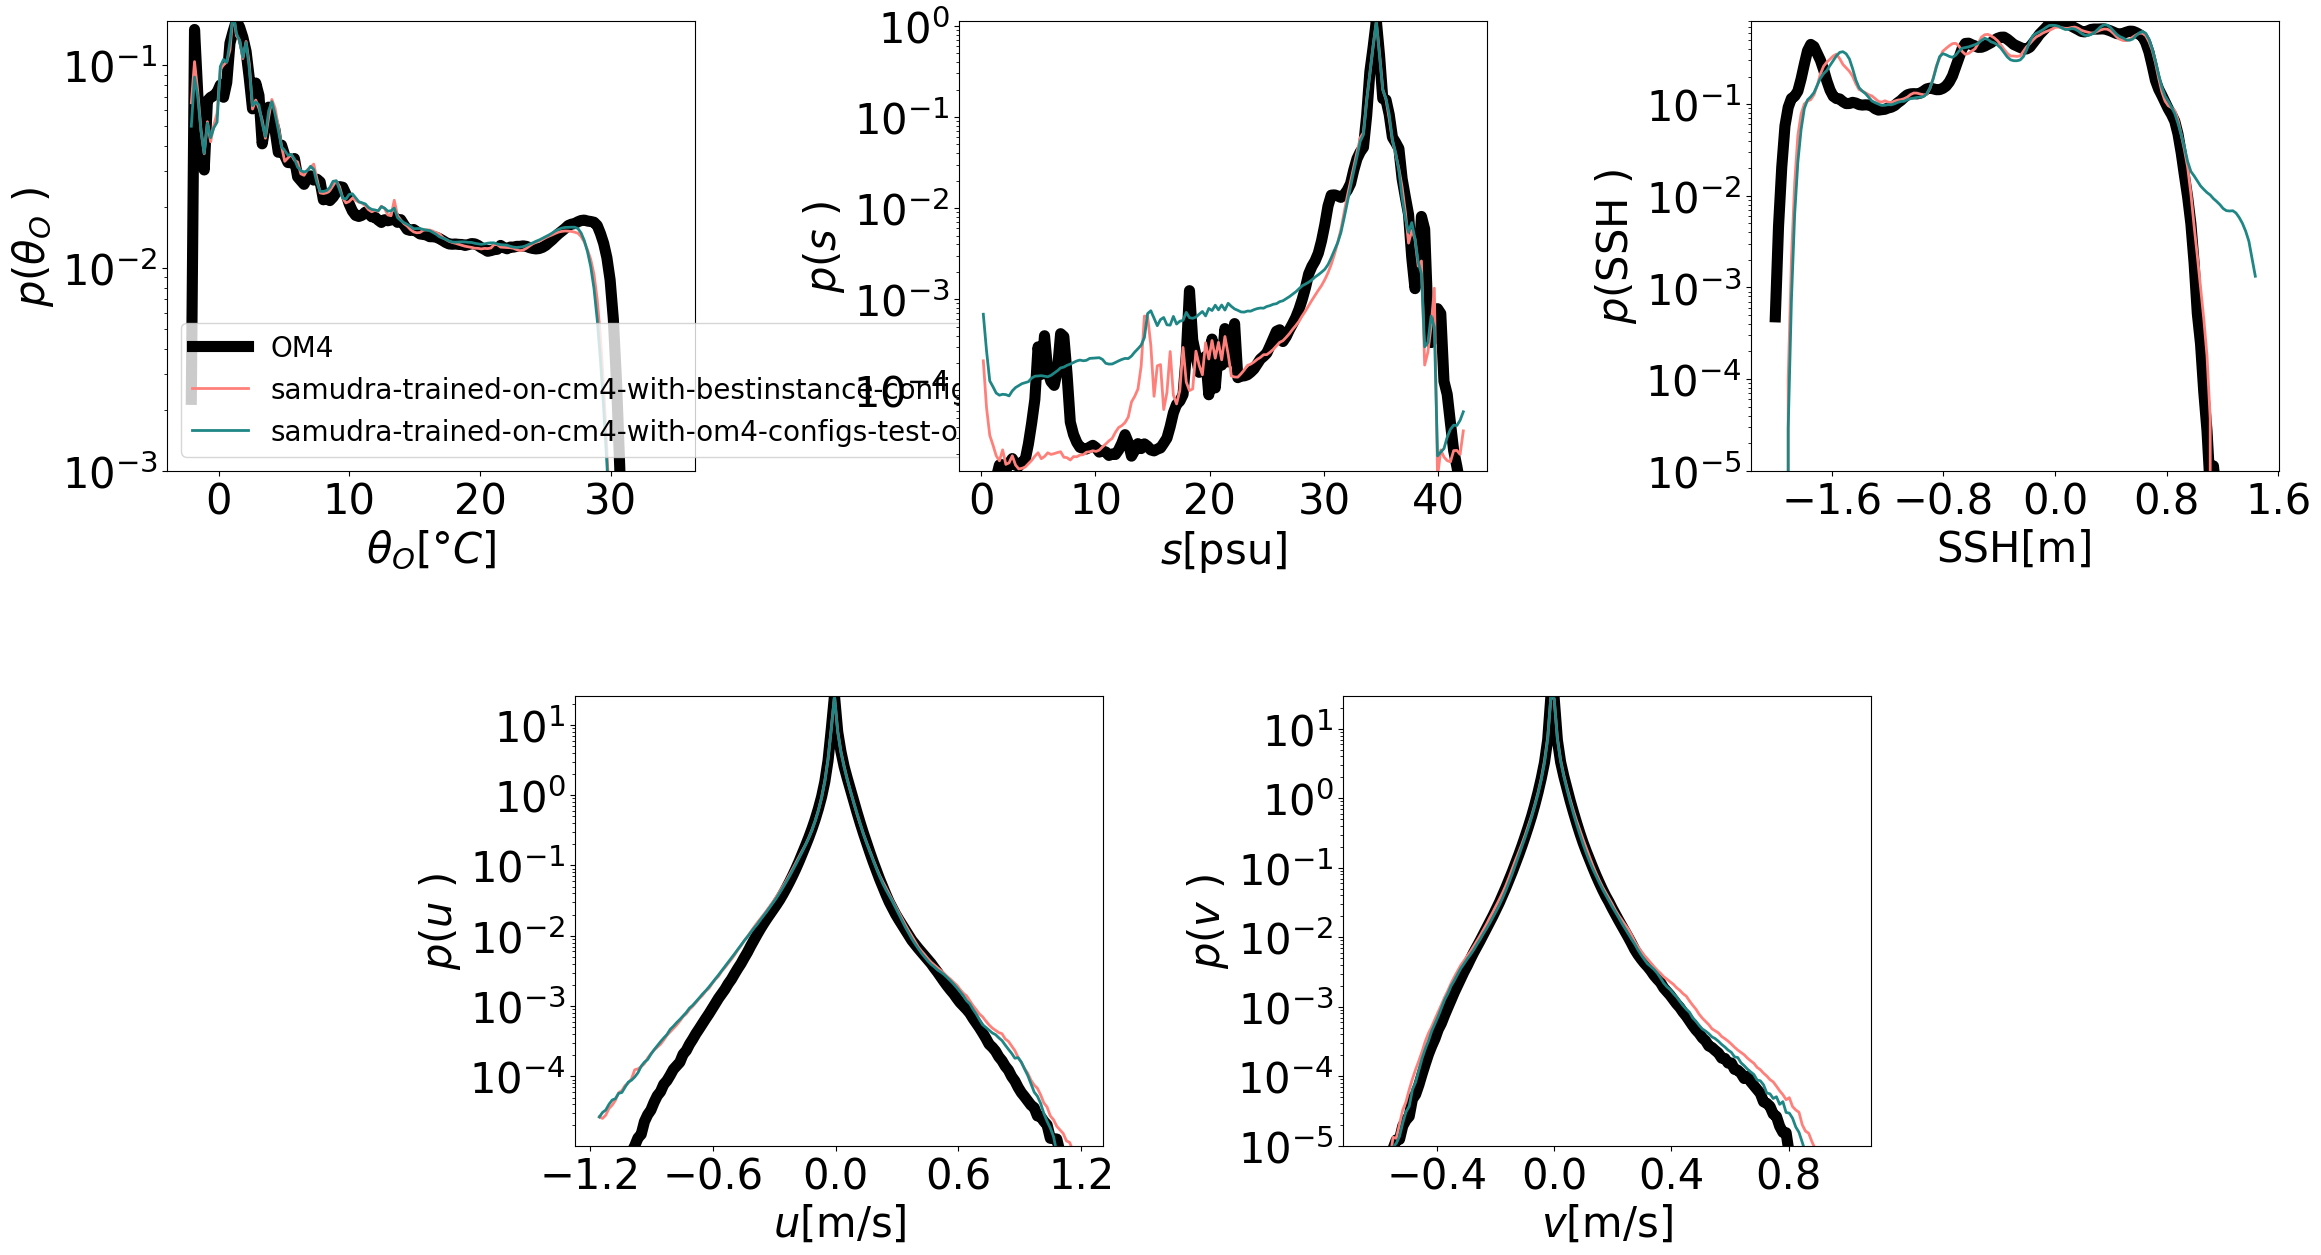

In [105]:
plt.rcParams.update({"font.size": 9})
# Create a figure
fig = plt.figure(figsize=(24, 15))
plt.rc("axes", titlesize=30)  # fontsize of the axes title
plt.rc("axes", labelsize=30)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=30)  # fontsize of the tick labels
plt.rc("ytick", labelsize=30)  # fontsize of the tick labels
plt.rc("legend", fontsize=20)  # legend fontsize
plt.rc("figure", titlesize=30)
# Manual positioning using add_axes with uniform width and height
width = 0.22
height = 0.3

# Top row: 3 plots, evenly spaced horizontally
axs = [
    fig.add_axes([0.05, 0.55, width, height]),  # First plot in top row
    fig.add_axes([0.38, 0.55, width, height]),  # Second plot in top row
    fig.add_axes([0.71, 0.55, width, height]),  # Third plot in top row
]

# Bottom row: 2 plots centered, manually positioned
axs += [
    fig.add_axes([0.22, 0.1, width, height]),  # First plot in bottom row
    fig.add_axes([0.54, 0.1, width, height]),  # Second plot in bottom row
]

# Plot PDFs
for i, v in enumerate(["thetao", "so", "zos", "uo", "vo"]):
    min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(
        data[v], bins=150, density=True, range=(min_val, max_val)
    )
    axs[i].semilogy(bins_true[:-1], true_pdf, label=dataset_name, color="k", lw=8)

    for j, k in enumerate(pred_dict.keys()):
        if v in pred_dict[k]["ls"]:
            pdf_net, bins_net = np.histogram(
                pred_dict[k]["ds_prediction"][v],
                bins=150,
                density=True,
                range=(min_val, max_val),
            )
            axs[i].semilogy(
                bins_net[:-1], pdf_net, label=pred_dict[k]["name"], color=clist[j], lw=2
            )

    axs[i].xaxis.set_major_locator(MaxNLocator(5, prune="both"))
    if i == 0:
        axs[i].legend()
    axs[i].set_xlabel(r"" + data[v].long_name + "[" + data[v].units + "]")
    axs[i].set_ylabel(r"${p(}$" + data[v].long_name + " " + "${)}$")

    if v not in ["thetao", "SSH"]:
        axs[i].set_ylim([min(true_pdf.min(), pdf_net.min()) + 1e-5, true_pdf.max()])
    else:
        axs[i].set_ylim([1e-3, true_pdf.max()])
matplotlib.style.use("default")

# Save or show the figure
# plt.show()
plt.savefig(os.path.join(pdfs_path, "PDF_Plots_Short"), bbox_inches="tight", dpi=600)

### ENSO

In [106]:
clim = data["thetao"].sel(lev=slice(0, 500)).groupby("time.dayofyear").mean().compute()
data_surface = data.sel(lev=slice(0, 500))
for k in pred_dict.keys():
    pred_dict[k]["ds_prediction_surface"] = pred_dict[k]["ds_prediction"].sel(
        lev=slice(0, 500)
    )
    pred_dict[k]["clim_pred"] = (
        pred_dict[k]["ds_prediction_surface"]["thetao"]
        .groupby("time.dayofyear")
        .mean()
        .compute()
    )

In [107]:
def NinoIndexComputeClim(T, area, dt=5, window=150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x=slice(190, 240), y=slice(-5, 5))
    area = area.sel(x=slice(190, 240), y=slice(-5, 5)).load()
    clim = T_clim.groupby("time.dayofyear").mean("time").compute()
    window = int(window / dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i] - clim.sel(dayofyear=day)).data

    T_clim = T_clim.rolling(time=window).mean()
    # T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])
    T_clim = T_clim.weighted(area).mean(["x", "y"])

    return T_clim[window:]

In [108]:
nino_true_compute_clim = NinoIndexComputeClim(
    data_surface["thetao"][:, 0], data["areacello"]
)
nino_true_compute_clim = nino_true_compute_clim.rename("Nino 3.4")
nino_true_compute_clim = nino_true_compute_clim.assign_attrs(units=r"$\degree C$")

for k in pred_dict.keys():
    pred_dict[k]["nino_pred_compute_clim"] = NinoIndexComputeClim(
        pred_dict[k]["ds_prediction_surface"]["thetao"][:, 0],
        pred_dict[k]["ds_prediction"]["areacello"],
    )
    pred_dict[k]["nino_pred_compute_clim"] = pred_dict[k][
        "nino_pred_compute_clim"
    ].rename("Nino 3.4")
    pred_dict[k]["nino_pred_compute_clim"] = pred_dict[k][
        "nino_pred_compute_clim"
    ].assign_attrs(units=r"$\degree C$")

In [109]:
day_max = int(
    (
        np.argwhere(
            nino_true_compute_clim.values
            == np.nanmax(nino_true_compute_clim.values[5:-5])
        )
        + 30
    ).squeeze()
)
day_min = int(
    (
        np.argwhere(
            nino_true_compute_clim.values
            == np.nanmin(nino_true_compute_clim.values[5:-5])
        )
        + 30
    ).squeeze()
)

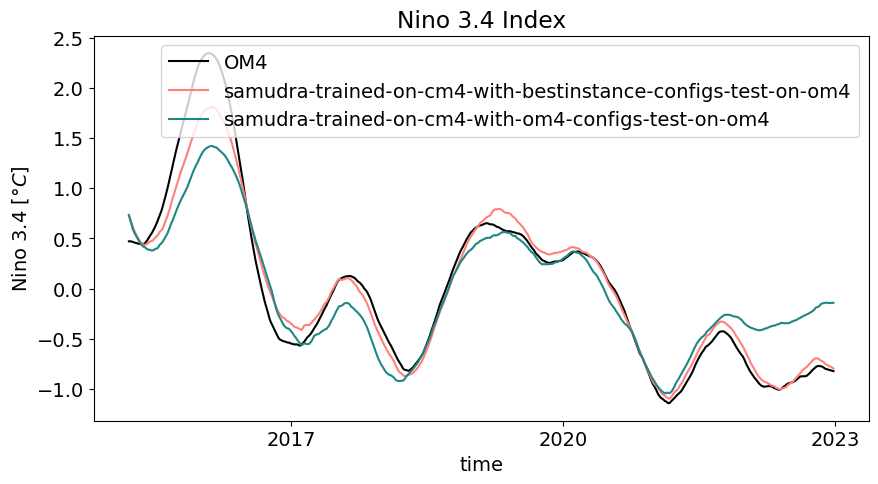

In [110]:
plt.rcParams.update({"font.size": 14})
plt.figure(figsize=[10, 5])
nino_true_compute_clim.plot(label=dataset_name, c="k")
for i, k in enumerate(pred_dict.keys()):
    pred_dict[k]["nino_pred_compute_clim"].plot(label=pred_dict[k]["name"], c=clist[i])

ax = plt.gca()
ax.legend()
ax.set_title("Nino 3.4 Index")

plt.savefig(os.path.join(enso_path, "Climatology"), bbox_inches="tight", dpi=600)

In [111]:
for k in pred_dict.keys():
    mae = np.abs(
        (pred_dict[k]["nino_pred_compute_clim"] - nino_true_compute_clim).mean(["time"])
    )
    cor = (
        (pred_dict[k]["nino_pred_compute_clim"] * nino_true_compute_clim)
        / np.sqrt(
            (pred_dict[k]["nino_pred_compute_clim"] ** 2) * (nino_true_compute_clim**2)
        )
    ).mean()
    print(pred_dict[k]["name"], "mae: ", mae.item(), "cor: ", cor.item())

samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4 mae:  0.012186282139855944 cor:  0.9436619718309859
samudra-trained-on-cm4-with-om4-configs-test-on-om4 mae:  0.03139539871143356 cor:  0.852112676056338


### Profiles and Maps

In [112]:
keys = list(pred_dict.keys())
# assert len(keys) >= 2, "Maps supported by atleast two keys"
key1 = keys[0]

#### ENSO Maps

samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4 El Nino mae:  0.006885807305947529 El Nino cor:  0.9352031447500947
samudra-trained-on-cm4-with-bestinstance-configs-test-on-om4 La Nina mae:  0.12743608634219344 La Nina cor:  0.9341018312042318


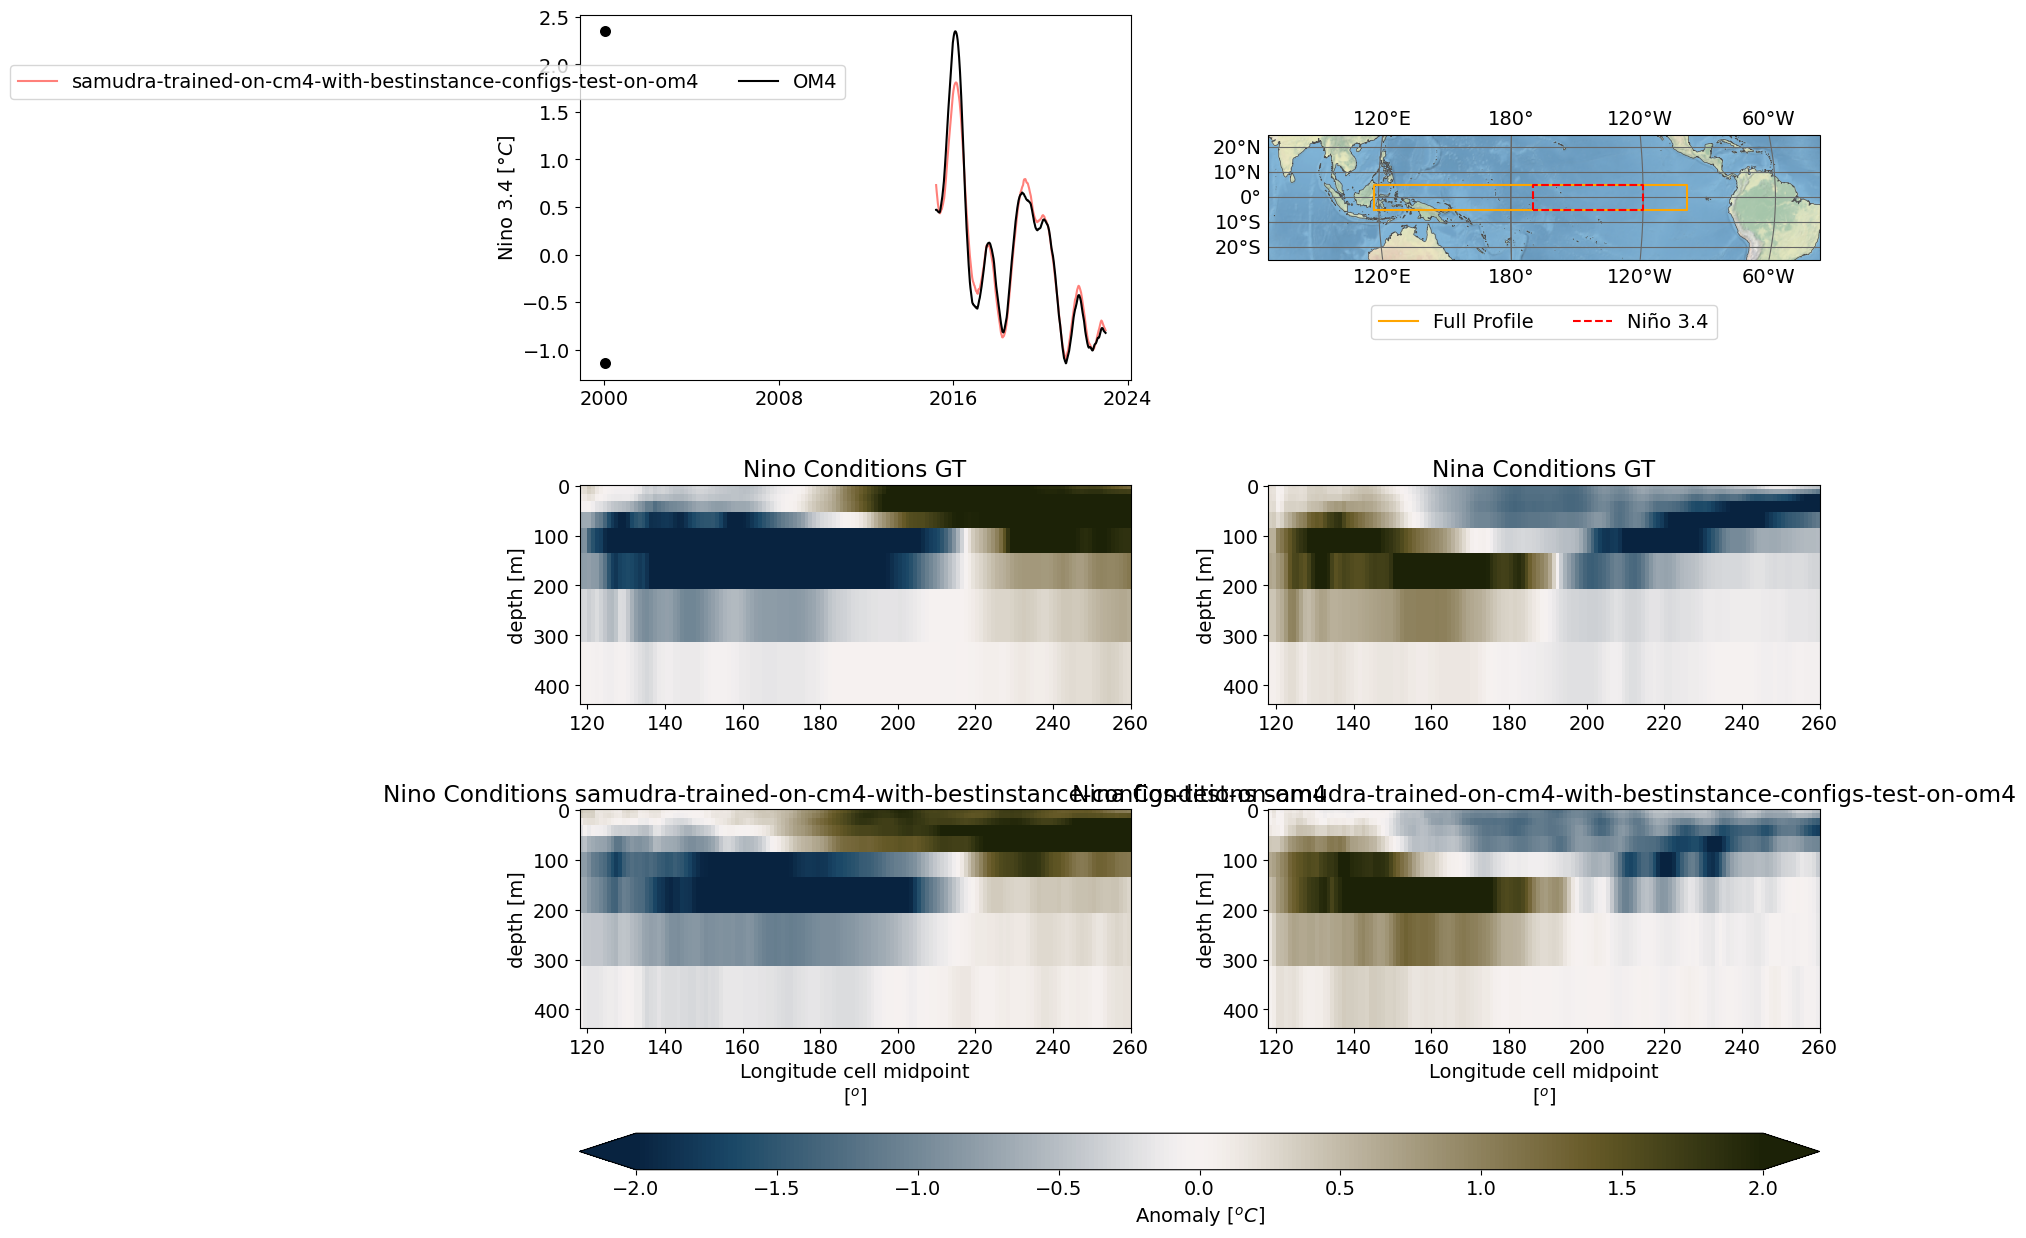

In [113]:
plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplot_mosaic(
    [
        ["time series", "map"],
        ["nino_true", "nina_true"],
        ["nino_pred", "nina_pred"],
        ["colorbar", "colorbar"],
    ],
    figsize=(16, 15),
    per_subplot_kw={"map": dict(projection=ccrs.Robinson(190))},
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [0.5, 0.3, 0.3, 0.05],
        "wspace": 0.25,
        "hspace": 0.5,
    },
)

############################################
# Time Series
############################################
pred_dict[key1]["nino_pred_compute_clim"].plot(
    label=pred_dict[key1]["name"], c=clist[0], ax=axs["time series"]
)

nino_true_compute_clim.plot(label=dataset_name, c="k", ax=axs["time series"])
nino_true_compute_clim.isel(time=slice(day_max - 30, day_max - 30 + 1)).drop_vars(
    ["lev"]
).plot.scatter(s=80, c="k", ax=axs["time series"])
nino_true_compute_clim.isel(time=slice(day_min - 30, day_min - 30 + 1)).drop_vars(
    ["lev"]
).plot.scatter(s=80, c="k", ax=axs["time series"])

axs["time series"].set_title("")
axs["time series"].set_xlabel("")
axs["time series"].legend(ncols=3, bbox_to_anchor=(0.5, 0.89))
# axs['time series'].set_title('Nino 3.4 Index')

############################################
# El Nino Tropics Profiles
############################################

day_start = day_max
window = 3

time_slice = slice(
    pred_dict[key1]["ds_prediction_surface"]["time"][day_start],
    pred_dict[key1]["ds_prediction_surface"]["time"][day_start + window],
)
times = pred_dict[key1]["ds_prediction"]["time"][day_start : day_start + window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear=days_of_year).rename({"dayofyear": "time"})
true_clim_to_remove["time"] = times
pred_clim_to_remove = (
    pred_dict[key1]["clim_pred"]
    .sel(dayofyear=days_of_year)
    .rename({"dayofyear": "time"})
)
pred_clim_to_remove["time"] = times

tropics_profile = (
    data_surface["thetao"].sel(time=time_slice, x=slice(118, 260), y=slice(-5, 5))
    - true_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred = (
    pred_dict[key1]["ds_prediction_surface"]["thetao"][
        day_start : day_start + window
    ].sel(lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5))
    - pred_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile = tropics_profile.rename("Anomaly")
tropics_profile_pred = tropics_profile_pred.rename("Anomaly")
tropics_profile = tropics_profile.assign_attrs(units=r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units=r"${^oC}$")
tropics_profile_pred["x"] = tropics_profile_pred["x"].assign_attrs(units=r"${^o}$")


tropics_profile.plot.pcolormesh(
    ax=axs["nino_true"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nino_true"].set_title("Nino Conditions GT")
axs["nino_true"].set_xlabel("")
axs["nino_true"].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(
    ax=axs["nino_pred"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nino_pred"].set_title(f"Nino Conditions {pred_dict[key1]['name']}")
axs["nino_pred"].invert_yaxis()

## Stats
# for name,pred in zip([pred_dict[key1]["name"], pred_dict[key2]["name"]], [tropics_profile_pred, tropics_profile_pred_temp]):
#     mae = np.abs((pred - tropics_profile).mean(['x', 'lev']))
#     cor = ((pred*tropics_profile)).mean(['x', 'lev']) / np.sqrt((pred**2).mean(['x', 'lev']) * (tropics_profile**2).mean(['x', 'lev']))

#     print(name, "mae: ", mae.compute().item(), "cor: ", cor.compute().item())

for name, pred in zip(
    [pred_dict[key1]["name"]],
    [tropics_profile_pred],
):
    mae = np.abs((pred - tropics_profile).weighted(data["dz"]).mean(["x", "lev"]))
    cor = (pred * tropics_profile).weighted(data["dz"]).mean(["x", "lev"]) / np.sqrt(
        (pred**2).weighted(data["dz"]).mean(["x", "lev"])
        * (tropics_profile**2).weighted(data["dz"]).mean(["x", "lev"])
    )

    print(
        name,
        "El Nino mae: ",
        mae.compute().item(),
        "El Nino cor: ",
        cor.compute().item(),
    )

############################################
# La Nina Tropics Profiles
############################################

day_start = day_min
window = 3

time_slice = slice(
    pred_dict[key1]["ds_prediction"]["time"][day_start],
    pred_dict[key1]["ds_prediction"]["time"][day_start + window],
)
times = pred_dict[key1]["ds_prediction"]["time"][day_start : day_start + window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear=days_of_year).rename({"dayofyear": "time"})
true_clim_to_remove["time"] = times
pred_clim_to_remove = (
    pred_dict[key1]["clim_pred"]
    .sel(dayofyear=days_of_year)
    .rename({"dayofyear": "time"})
)
pred_clim_to_remove["time"] = times

tropics_profile = (
    data_surface["thetao"].sel(time=time_slice, x=slice(118, 260), y=slice(-5, 5))
    - true_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred = (
    pred_dict[key1]["ds_prediction_surface"]["thetao"][
        day_start : day_start + window
    ].sel(lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5))
    - pred_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])

tropics_profile = tropics_profile.rename("Anomaly")
tropics_profile_pred = tropics_profile_pred.rename("Anomaly")
tropics_profile = tropics_profile.assign_attrs(units=r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units=r"${^oC}$")
tropics_profile_pred["x"] = tropics_profile_pred["x"].assign_attrs(units=r"${^o}$")

tropics_profile.plot.pcolormesh(
    ax=axs["nina_true"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nina_true"].set_title("Nina Conditions GT")
axs["nina_true"].set_xlabel("")
axs["nina_true"].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(
    ax=axs["nina_pred"],
    y="lev",
    cmap=cm.cm.diff,
    vmin=-2,
    vmax=2,
    cbar_ax=axs["colorbar"],
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.3,
        "extend": "both",
    },
)
axs["nina_pred"].set_title(f"Nina Conditions {pred_dict[key1]['name']}")
axs["nina_pred"].invert_yaxis()

## Stats
# for name,pred in zip([pred_dict[key1]["name"], pred_dict[key2]["name"]], [tropics_profile_pred, tropics_profile_pred_temp]):
#     mae = np.abs((pred - tropics_profile).mean(['x', 'lev']))
#     cor = ((pred*tropics_profile)).mean(['x', 'lev']) / np.sqrt((pred**2).mean(['x', 'lev']) * (tropics_profile**2).mean(['x', 'lev']))

#     print(name, "mae: ", mae.compute().item(), "cor: ", cor.compute().item())

for name, pred in zip(
    [pred_dict[key1]["name"]],
    [tropics_profile_pred],
):
    mae = np.abs((pred - tropics_profile).weighted(data["dz"]).mean(["x", "lev"]))
    cor = (pred * tropics_profile).weighted(data["dz"]).mean(["x", "lev"]) / np.sqrt(
        (pred**2).weighted(data["dz"]).mean(["x", "lev"])
        * (tropics_profile**2).weighted(data["dz"]).mean(["x", "lev"])
    )

    print(
        name,
        "La Nina mae: ",
        mae.compute().item(),
        "La Nina cor: ",
        cor.compute().item(),
    )

############################################
# Maps
############################################
# maybe define this centrally and use for all plots from this variable?
bound_east = 118  # i think these are outdated?
bound_west = 260
bound_north = 5
bound_south = -5
# nino 3.4 box
# nino 3.4 box
nino_east = 190
nino_west = 240

axs["map"].set_extent([70, 320, -25, 25], crs=ccrs.PlateCarree())
axs["map"].stock_img()
axs["map"].coastlines(color="0.3", lw=0.5)
gl = axs["map"].gridlines(draw_labels=True, color="0.4")
box_plot(
    [bound_east, bound_west, bound_south, bound_north],
    ax=axs["map"],
    color="orange",
    transform=ccrs.PlateCarree(),
    label="Full Profile",
)
box_plot(
    [nino_east, nino_west, bound_south, bound_north],
    ax=axs["map"],
    color="red",
    ls="--",
    transform=ccrs.PlateCarree(),
    label="Niño 3.4",
)
axs["map"].legend(bbox_to_anchor=[0.5, -0.5], loc="center", ncol=2)

plt.savefig(
    os.path.join(enso_path, "Nino_Figure_Short_with_map_single.png"),
    bbox_inches="tight",
    dpi=600,
)

#### OHC Maps

KeyboardInterrupt: 

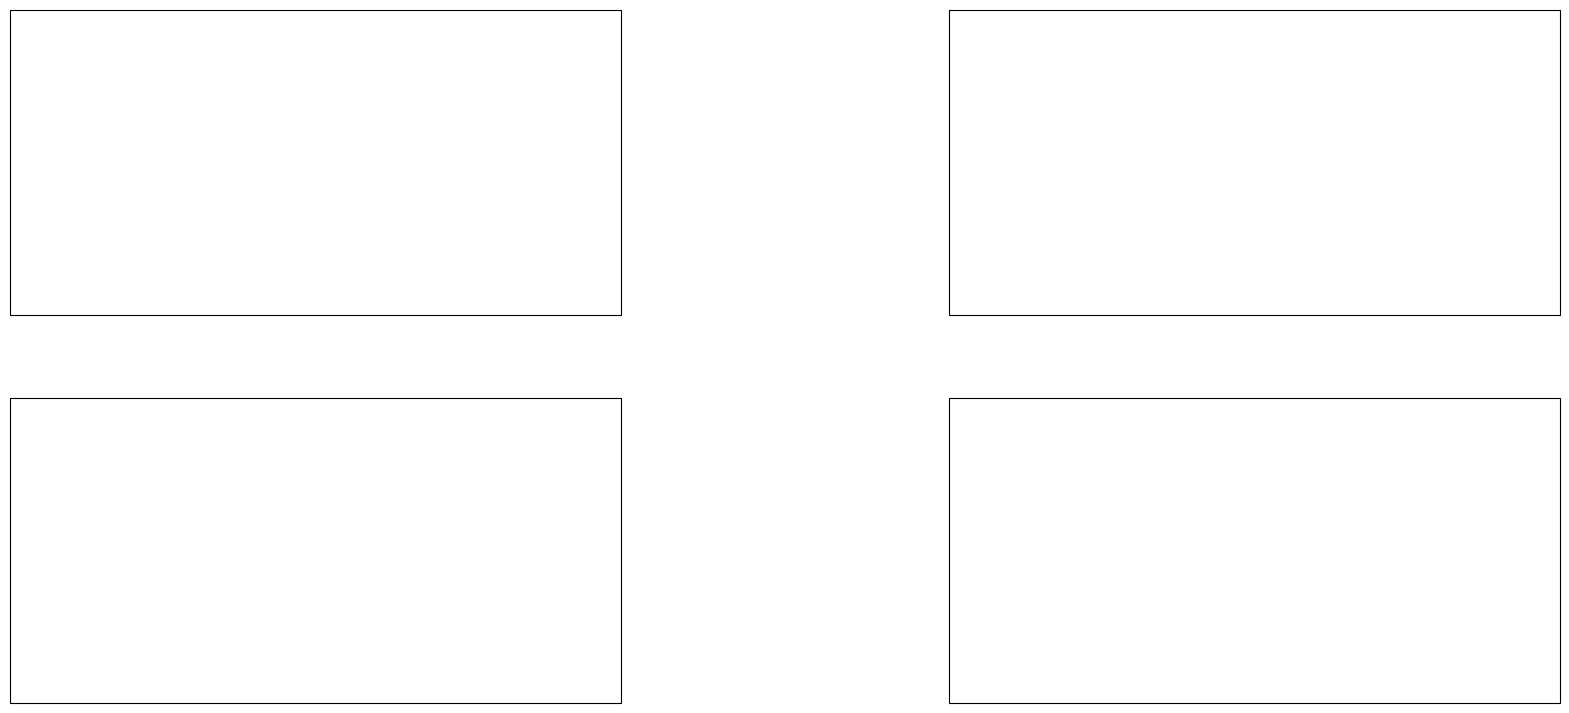

In [114]:
# OHC Map + Bias
Days_to_Eq = 0
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
zeta_joules_factor = 1e21  # Conversion factor to ZJ

plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplots(
    2,
    2,
    figsize=(24, 9),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.02, "hspace": 0.27},
)
axs = axs.flatten()


def ohc_map(ohc_intz):
    ohc_intz = remove_climatology(ohc_intz)
    # return last 1 year - first 1 year
    return ohc_intz.isel(time=slice(-73, None)).mean("time") - ohc_intz.isel(
        time=slice(0, 73)
    ).mean("time")


# Define a common plotting function for Cartesian lat-lon grids


def plot_ohc(ax, ohc_data, title, i):
    # Configure colormap and set color for NaN values (land)
    colormap = cm.cm.balance  # cm.cm.thermal  # Using thermal colormap from cmocean
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    mean = ohc_data.mean().compute().item()
    std = ohc_data.std().compute().item()
    vmin = mean - 4 * std
    vmax = mean + 4 * std
    im = ax.pcolormesh(
        ohc_data["x"],
        ohc_data["y"],
        ohc_data,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    # Set longitude and latitude labels
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im


def plot_diff_ohc(ax, ohc_data, gt_ohc_data, title, i):
    # Configure colormap and set color for NaN values (land)
    colormap = cm.cm.balance  # Using thermal colormap from cmocean
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    bias_ohc = ohc_data - gt_ohc_data
    mean = ohc_data.mean().compute().item()
    std = ohc_data.std().compute().item()
    vmin = mean - 4 * std
    vmax = mean + 4 * std
    im = ax.pcolormesh(
        bias_ohc["x"],
        bias_ohc["y"],
        bias_ohc,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    # Set longitude and latitude labels
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    # if i > 4:
    #     gl.left_labels = False
    return im


# Calculate Ocean Heat Content for different scenarios and convert to Zeta Joules
titles = [dataset_name, pred_dict[key1]["name"]]
bias_titles = [pred_dict[key1]["name"] + " Bias"]
datasets = [data, pred_dict[key1]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds["thetao"]).all("lev").isel(time=5)
    OHC_pred = (
        (ds["thetao"][Days_to_Eq:] * c_p * rho_0 / zeta_joules_factor)
        .weighted(ds["areacello"] * ds["dz"])
        .sum(["lev"])
        .compute()
    )
    OHC_pred = ohc_map(OHC_pred)
    OHC_pred = OHC_pred.where(~section_mask)
    OHC_pred = OHC_pred.rename("Ocean Heat Content")
    OHC_pred["y"] = OHC_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
    OHC_pred["x"] = OHC_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
    OHC_pred = OHC_pred.assign_attrs(units="ZJ")

    if i == 0:
        gt_ohc = OHC_pred
    elif i == 1:
        pred1_ohc = OHC_pred

    # Plot using the Cartesian lat-lon grid
    im = plot_ohc(ax, OHC_pred, title, i)

# Add colorbar
cbar = fig.colorbar(im, ax=axs[:2], orientation="vertical", fraction=0.01, pad=0.02)
cbar.set_label("Ocean Heat Content [ZJ]", fontsize=14)

im = plot_diff_ohc(axs[3], pred1_ohc, gt_ohc, bias_titles[0], 4)

# Add colorbar
cbar = fig.colorbar(im, ax=axs[3:], orientation="vertical", fraction=0.1, pad=0.02)
cbar.set_label("Ocean Heat Content [ZJ]", fontsize=14)

fig.delaxes(axs[2])

fig.suptitle("OHC Anomaly (Last Year - First Year) and Bias", fontsize=14, y=0.95)
# Save or display the plot
plt.savefig(os.path.join(ohc_path, "OHC_Global_map.png"), bbox_inches="tight", dpi=600)
# plt.show()

In [ ]:
def map_bias_avg(data_pred1, fig, title="", **kwargs):
    var_name = kwargs["var_name"]

    plt.clf()
    plt.rcParams.update({"font.size": 14})

    # Define colormap
    new_cmap = cm.cm.balance
    new_cmap.set_bad(color="grey", alpha=0.0)

    # Set common color range for the colorbar
    vmin, vmax = {
        "thetao": (-5, 5),
        "so": (-1, 1),
        "uo": (-0.01, 0.01),
        "vo": (-0.01, 0.01),
        "zos": (-1, 1),
        "OHC": (-0.05, 0.05),
    }[var_name]

    # Create figure with one subplot
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Plot Prediction
    im = data_pred1.plot(
        ax=ax,
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax.set_title(pred_dict[key1]["name"] + " Bias", fontsize=14)

    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label(var_list[var_name])

    # Add title
    plt.text(
        0.5,
        1.1,
        title,
        ha="center",
        va="bottom",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
    )

    return ax, im

In [ ]:
first_year = slice(None, 73)
last_year = slice(-73, -1)
second_last_year = slice(-146, -74)
third_last_year = slice(-219, -147)


datasets = [data, pred_dict[key1]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds["thetao"]).all("lev")
    OHC_pred = (
        (ds["thetao"][Days_to_Eq:] * c_p * rho_0 / zeta_joules_factor)
        .weighted(ds["areacello"] * ds["dz"])
        .sum(["lev"])
        .compute()
    )
    OHC_pred = remove_climatology(OHC_pred)
    OHC_pred = OHC_pred.where(~section_mask)
    OHC_pred = OHC_pred.rename("OHC Anomaly")
    OHC_pred["y"] = OHC_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
    OHC_pred["x"] = OHC_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
    OHC_pred = OHC_pred.assign_attrs(units="ZJ")

    if i == 0:
        gt_ohc = OHC_pred
    elif i == 1:
        pred1_ohc = OHC_pred

In [ ]:
da = (
    pred1_ohc.isel(time=last_year).mean("time")
    - pred1_ohc.isel(time=second_last_year).mean("time")
).compute()
fig, ax = plt.subplots(figsize=(10, 10))
# increase size of plot
ax, im = map_bias_avg(
    da,
    fig,
    var_name="OHC",
    title="OHC Bias (Last Year - Second Last Year)",
)

# plot
fig.tight_layout()
plt.savefig(
    os.path.join(ohc_path, "OHC_Bias_Map_Diff1_2.png"),
    bbox_inches="tight",
    dpi=600,
)

In [ ]:
da = (
    pred1_ohc.isel(time=last_year).mean("time")
    - pred1_ohc.isel(time=third_last_year).mean("time")
).compute()
# increase size of plot
fig, ax = plt.subplots(figsize=(10, 10))
ax, im = map_bias_avg(
    da,
    fig,
    var_name="OHC",
    title="OHC Bias (Last Year - Third Last Year)",
)

# plot
fig.tight_layout()
plt.savefig(
    os.path.join(ohc_path, "OHC_Bias_Map_Diff1_3.png"),
    bbox_inches="tight",
    dpi=600,
)

In [ ]:
da = (
    pred1_ohc.isel(time=last_year).mean("time")
    - pred1_ohc.isel(time=first_year).mean("time")
).compute()
# increase size of plot
fig, ax = plt.subplots(figsize=(10, 10))
ax, im = map_bias_avg(
    da,
    fig,
    var_name="OHC",
    title="OHC Bias (Last Year - First Year)",
)

# plot
fig.tight_layout()
plt.savefig(
    os.path.join(ohc_path, "OHC_Bias_Map_Diff_Last_First.png"),
    bbox_inches="tight",
    dpi=600,
)

#### SST Map

In [ ]:
Days_to_Eq = 0
plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.02, "hspace": 0.23},
)
axs = axs.flatten()

# Define a common plotting function for Cartesian lat-lon grids


def plot_sst(ax, sst_data, title, i):
    colormap = cm.cm.thermal
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    mean = sst_data.mean().compute().item()
    std = sst_data.std().compute().item()
    vmin = mean - std
    vmax = mean + std
    im = ax.pcolormesh(
        sst_data["x"],
        sst_data["y"],
        sst_data,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im


def plot_diff_sst(ax, sst_data, gt_sst_data, title, i):
    colormap = cm.cm.balance
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    sst_bias = sst_data - gt_sst_data
    mean = sst_bias.mean().compute().item()
    std = sst_bias.std().compute().item()
    vmax = 1
    vmin = -vmax
    im = ax.pcolormesh(
        sst_bias["x"],
        sst_bias["y"],
        sst_bias,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    return im


# Calculate Sea Surface Temperature (SST) for different scenarios
titles = [dataset_name, pred_dict[key1]["name"]]
bias_titles = [pred_dict[key1]["name"] + " Bias"]
datasets = [data, pred_dict[key1]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds["thetao"]).isel(lev=0).isel(time=5)
    SST_pred = ds["thetao"].isel(lev=0).mean("time")
    SST_pred = SST_pred.where(~section_mask)
    SST_pred = SST_pred.rename("2.5m " + r"$\theta_O$")
    SST_pred["y"] = SST_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
    SST_pred["x"] = SST_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
    SST_pred = SST_pred.assign_attrs(units=r"$\degree C$")

    if i == 0:
        gt_sst = SST_pred
    elif i == 1:
        pred1_sst = SST_pred

    # Plot using the Cartesian lat-lon grid
    im = plot_sst(ax, SST_pred, title, i)

# Add colorbar for SST plots
cbar = fig.colorbar(im, ax=axs[:2], orientation="vertical", fraction=0.01, pad=0.02)
cbar.set_label(r"$\theta_O$ [$\degree C$]", fontsize=14)

# Plot biases for SST
im = plot_diff_sst(axs[3], pred1_sst, gt_sst, bias_titles[0], 3)

# Add colorbar for bias plots
cbar = fig.colorbar(im, ax=axs[3:], orientation="vertical", fraction=0.1, pad=0.02)
cbar.set_label(r"$\theta_O$ [$\degree C$]", fontsize=14)

# Remove the empty axis
fig.delaxes(axs[2])

fig.suptitle("2.5m Potential Temperature", fontsize=14, y=1.0)

# Save or display the plot
plt.savefig(os.path.join(temp_path, "SST_Global_map.png"), bbox_inches="tight", dpi=600)
# plt.show()

In [ ]:
# Single Snapshot (First, Middle, Last)
time_indices = [0, 300, 599]
Days_to_Eq = 0


def plot_sst(ax, sst_data, title, i):
    colormap = cm.cm.thermal
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    mean = sst_data.mean().compute().item()
    std = sst_data.std().compute().item()
    vmin = mean - std
    vmax = mean + std
    im = ax.pcolormesh(
        sst_data["x"],
        sst_data["y"],
        sst_data,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im


def plot_diff_sst(ax, sst_data, gt_sst_data, title, i):
    colormap = cm.cm.balance
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    sst_bias = sst_data - gt_sst_data
    im = ax.pcolormesh(
        sst_bias["x"],
        sst_bias["y"],
        sst_bias,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    return im


# Calculate Sea Surface Temperature (SST) for different scenarios

for t_index in time_indices:
    plt.rcParams.update({"font.size": 14})
    fig, axs = plt.subplots(
        2,
        2,
        figsize=(16, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.02, "hspace": 0.23},
    )
    axs = axs.flatten()

    # Define a common plotting function for Cartesian lat-lon grids

    titles = [dataset_name + f" t={t_index}", pred_dict[key1]["name"] + f" t={t_index}"]
    bias_titles = [pred_dict[key1]["name"] + " Bias"]
    datasets = [
        data,
        pred_dict[key1]["ds_prediction"],
    ]

    for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
        section_mask = np.isnan(ds["thetao"]).isel(lev=0).isel(time=5)
        SST_pred = ds["thetao"].isel(lev=0).isel(time=t_index)
        SST_pred = SST_pred.where(~section_mask)
        SST_pred = SST_pred.rename("2.5m " + r"$\theta_O$")
        SST_pred["y"] = SST_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
        SST_pred["x"] = SST_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
        SST_pred = SST_pred.assign_attrs(units=r"$\degree C$")

        if i == 0:
            gt_sst = SST_pred
        elif i == 1:
            pred1_sst = SST_pred

        # Plot using the Cartesian lat-lon grid
        im = plot_sst(ax, SST_pred, title, i)

    # Add colorbar for SST plots
    cbar = fig.colorbar(im, ax=axs[:2], orientation="vertical", fraction=0.01, pad=0.02)
    cbar.set_label(r"$\theta_O$ [$\degree C$]", fontsize=14)

    # Plot biases for SST
    im = plot_diff_sst(axs[3], pred1_sst, gt_sst, bias_titles[0], 3)

    # Add colorbar for bias plots
    cbar = fig.colorbar(im, ax=axs[3:], orientation="vertical", fraction=0.1, pad=0.02)
    cbar.set_label(r"$\theta_O$ [$\degree C$]", fontsize=14)

    # Remove the empty axis
    fig.delaxes(axs[2])

    # Save or display the plot
    plt.savefig(
        os.path.join(temp_path, f"SST_map_snapshot_t_{t_index}.png"),
        bbox_inches="tight",
        dpi=600,
    )
    # plt.show()
    plt.close()

#### Salinity Map

In [ ]:
Days_to_Eq = 0
plt.rcParams.update({"font.size": 14})
fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.02, "hspace": 0.23},
)
axs = axs.flatten()

# Define a common plotting function for Cartesian lat-lon grids


def plot_sst(ax, sst_data, title, i):
    colormap = cm.cm.thermal
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    mean = sst_data.mean().compute().item()
    std = sst_data.std().compute().item()
    vmin = mean - std
    vmax = mean + std
    im = ax.pcolormesh(
        sst_data["x"],
        sst_data["y"],
        sst_data,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im


def plot_diff_sst(ax, sst_data, gt_sst_data, title, i):
    colormap = cm.cm.balance
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    sst_bias = sst_data - gt_sst_data
    im = ax.pcolormesh(
        sst_bias["x"],
        sst_bias["y"],
        sst_bias,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=-0.5,
        vmax=0.5,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    return im


# Calculate Sea Surface Salinity (SSS) for different scenarios
titles = [dataset_name, pred_dict[key1]["name"]]
bias_titles = [pred_dict[key1]["name"] + " Bias"]
datasets = [data, pred_dict[key1]["ds_prediction"]]

for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
    section_mask = np.isnan(ds["so"]).isel(lev=0).isel(time=5)
    SST_pred = ds["so"].isel(lev=0).mean("time")
    SST_pred = SST_pred.where(~section_mask)
    SST_pred = SST_pred.rename("2.5m " + r"$so$")
    SST_pred["y"] = SST_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
    SST_pred["x"] = SST_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
    SST_pred = SST_pred.assign_attrs(units=r"$psu$")

    if i == 0:
        gt_sst = SST_pred
    elif i == 1:
        pred1_sst = SST_pred

    # Plot using the Cartesian lat-lon grid
    im = plot_sst(ax, SST_pred, title, i)

# Add colorbar for SST plots
cbar = fig.colorbar(im, ax=axs[:2], orientation="vertical", fraction=0.01, pad=0.02)
cbar.set_label(r"$so$ [$psu$]", fontsize=14)

# Plot biases for SST
im = plot_diff_sst(axs[3], pred1_sst, gt_sst, bias_titles[0], 3)

# Add colorbar for bias plots
cbar = fig.colorbar(im, ax=axs[3:], orientation="vertical", fraction=0.1, pad=0.02)
cbar.set_label(r"$so$ [$psu$]", fontsize=14)

# Remove the empty axis
fig.delaxes(axs[2])

# Save or display the plot
plt.savefig(
    os.path.join(salinity_path, "SeaSurfaceSalinity_Global_map.png"),
    bbox_inches="tight",
    dpi=600,
)
# plt.show()

In [ ]:
# Single Snapshot (First, Middle, Last)
time_indices = [0, 300, 599]
Days_to_Eq = 0


def plot_sst(ax, sst_data, title, i):
    colormap = cm.cm.thermal
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    mean = sst_data.mean().compute().item()
    std = sst_data.std().compute().item()
    vmin = mean - std
    vmax = mean + std
    im = ax.pcolormesh(
        sst_data["x"],
        sst_data["y"],
        sst_data,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    if i > 0:
        gl.left_labels = False
    return im


def plot_diff_sst(ax, sst_data, gt_sst_data, title, i):
    colormap = cm.cm.balance
    colormap.set_bad(color=(0.7, 0.7, 0.7, 0))
    sst_bias = sst_data - gt_sst_data
    im = ax.pcolormesh(
        sst_bias["x"],
        sst_bias["y"],
        sst_bias,
        shading="auto",
        cmap=colormap,
        transform=ccrs.PlateCarree(),
        vmin=-0.5,
        vmax=0.5,
    )
    ax.add_feature(cfeature.COASTLINE, edgecolor="black")
    ax.set_title(title, fontsize=14)
    gl = ax.gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    return im


for t_index in time_indices:
    plt.rcParams.update({"font.size": 14})
    fig, axs = plt.subplots(
        2,
        2,
        figsize=(16, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.02, "hspace": 0.23},
    )
    axs = axs.flatten()

    # Calculate Sea Surface Salinity (SSS) for different scenarios
    titles = [
        dataset_name + f" t={t_index}",
        pred_dict[key1]["name"] + f" t={t_index}",
    ]
    bias_titles = [pred_dict[key1]["name"] + " Bias"]
    datasets = [
        data,
        pred_dict[key1]["ds_prediction"],
    ]

    for i, (ax, title, ds) in enumerate(zip(axs, titles, datasets)):
        section_mask = np.isnan(ds["so"]).isel(lev=0).isel(time=5)
        SST_pred = ds["so"].isel(lev=0).isel(time=t_index)
        SST_pred = SST_pred.where(~section_mask)
        SST_pred = SST_pred.rename("2.5m " + r"$so$")
        SST_pred["y"] = SST_pred.y.assign_attrs(long_name="latitude", units=r"${^o}$")
        SST_pred["x"] = SST_pred.x.assign_attrs(long_name="longitude", units=r"${^o}$")
        SST_pred = SST_pred.assign_attrs(units=r"$psu$")

        if i == 0:
            gt_sst = SST_pred
        elif i == 1:
            pred1_sst = SST_pred

        # Plot using the Cartesian lat-lon grid
        im = plot_sst(ax, SST_pred, title, i)

    # Add colorbar for SST plots
    cbar = fig.colorbar(im, ax=axs[:2], orientation="vertical", fraction=0.01, pad=0.02)
    cbar.set_label(r"$so$ [$psu$]", fontsize=14)

    # Plot biases for SST
    im = plot_diff_sst(axs[3], pred1_sst, gt_sst, bias_titles[0], 3)

    # Add colorbar for bias plots
    cbar = fig.colorbar(im, ax=axs[3:], orientation="vertical", fraction=0.1, pad=0.02)
    cbar.set_label(r"$so$ [$psu$]", fontsize=14)

    # Remove the empty axis
    fig.delaxes(axs[2])

    # Save or display the plot
    plt.savefig(
        os.path.join(salinity_path, f"SSS_map_snapshot_t_{t_index}.png"),
        bbox_inches="tight",
        dpi=600,
    )
    # plt.show()

### Movies

In [11]:
import matplotlib as mpl

mpl.use("Agg")
import re
import os
import sys
import glob
import warnings
import gc
import xarray as xr
import cmocean as cm
from subprocess import Popen, PIPE, STDOUT
import matplotlib.pyplot as plt

import numpy as np
from cartopy.mpl import geoaxes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask.array as dsa
import matplotlib.ticker as mticker

from dask import delayed, compute
from dask.diagnostics import ProgressBar

try:
    from tqdm.auto import tqdm

    tqdm_avail = True
except:
    warnings.warn(
        "Optional dependency `tqdm` not found. This will make progressbars a lot nicer. \
    Install with `conda install -c conda-forge tqdm`"
    )
    tqdm_avail = False

Need atleast two keys otherwise duplicate maps

In [12]:
keys = list(pred_dict.keys())
# assert len(keys) >= 2, "Maps supported by atleast two keys"
key1 = keys[0]
if len(keys) == 1:
    print("Maps only support two models for now!!! Using the same key for both maps")
    key2 = keys[0]
elif len(keys) > 2:
    print("Maps only support two models for now!!! Using the first two keys")
    assert False
else:
    key2 = keys[1]

#### Core

In [13]:
def _core_plot(ax, data, plotmethod=None, **kwargs):
    """Core plotting functionality"""

    # Deactivate cbar for contours (not sure this should be hardcoded...)
    if plotmethod == "contour":
        kwargs.pop("cbar_kwargs", None)

    # I am probably recoding something from matplotlib...is there a way to get
    # the plot.something functionslity with a keyword?
    # For now do it the hard way
    if plotmethod is None:
        p = data.plot(ax=ax, **kwargs)
    # doesnt work,...i want this for smoother images
    elif plotmethod == "imshow":
        # p = data.plot.imshow(ax=ax, **kwargs)
        # testing interpolation
        p = data.plot.imshow(ax=ax, interpolation="gaussian", **kwargs)
        # print(p.get_interpolation())
    elif plotmethod == "pcolormesh":
        p = data.plot.pcolormesh(ax=ax, **kwargs)
    elif plotmethod == "contour":
        p = data.plot.contour(ax=ax, **kwargs)
    elif plotmethod == "contourf":
        p = data.plot.contourf(ax=ax, **kwargs)
    else:
        raise RuntimeError(
            "Input '%s' not recognized \
        as plotmode"
            % plotmethod
        )
    return p


def _base_plot(
    ax, base_data, timestamp, timestep_value, framedim, plotmethod=None, **kwargs
):
    data = base_data.isel({framedim: timestamp})
    p = _core_plot(ax, data, plotmethod=plotmethod, **kwargs)
    return p


### Presets (should proabably put all others into a submodule)
def basic(
    da,
    fig,
    timestamp,
    timestep_value,
    framedim="time",
    plotmethod=None,
    subplot_kw=None,
    **kwargs,
):
    # create axis
    ax = fig.subplots(subplot_kw=subplot_kw)
    pp = _base_plot(
        ax, da, timestamp, timestep_value, framedim, plotmethod=plotmethod, **kwargs
    )
    return ax, pp


# Data treatment


def _parse_plot_defaults(da, kwargs):
    if isinstance(da, xr.DataArray):
        data = da
    else:
        raise RuntimeError("input of type (%s) not supported yet." % type(da))

    # check these explicitly to avoid any computation if these are set.
    if "vmin" not in kwargs.keys():
        warnings.warn(
            "No `vmin` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `vmin` to avoid this step",
            UserWarning,
        )
        kwargs["vmin"] = data.min().data

    if "vmax" not in kwargs.keys():
        warnings.warn(
            "No `vmax` provided. Data limits are calculated from input. Depending on the input this can take long. Pass `vmax` to avoid this step",
            UserWarning,
        )
        kwargs["vmax"] = data.max().data

    # There is a bug that prevents this from working...Ill have to fix that upstream.
    # defaults["cbar_kwargs"] = dict(extend="neither")
    # This works for now
    kwargs.setdefault("extend", "neither")

    # if any value is dask.array compute them here.
    for k in ["vmin", "vmax"]:
        if isinstance(kwargs[k], dsa.Array):
            kwargs[k] = kwargs[k].compute()

    return kwargs


def _check_plotfunc_output(func, da, framedim="time", **kwargs):
    timestep = 0
    timestep_value = da[framedim].data[timestep]
    fig = plt.figure()
    oargs = func(da, fig, timestep, timestep_value, framedim, **kwargs)
    # I just want the number of output args, delete plot
    plt.close(fig)
    if oargs is None:
        return 0
    else:
        return len(oargs)


def _check_ffmpeg_version():
    p = Popen("ffmpeg -version", stdout=PIPE, shell=True)
    (output, err) = p.communicate()
    p_status = p.wait()
    # Parse version
    if p_status != 0:
        print("No ffmpeg found")
        return None
    else:
        # parse version number
        try:
            found = (
                re.search("ffmpeg version (.+?) Copyright", str(output))
                .group(1)
                .replace(" ", "")
            )
            return found
        except AttributeError:
            # ffmpeg version, Copyright not found in the original string
            found = None
    return found


def _execute_command(
    command, verbose=False, error=True, log_file="output.log", max_lines=10
):
    with open(log_file, "w") as f:
        p = Popen(
            command,
            stdout=PIPE,
            stderr=STDOUT,
            shell=True,
            bufsize=1,
            universal_newlines=True,
        )
        line_count = 0

        for line in iter(p.stdout.readline, ""):
            f.write(line)  # Write to log file

            if verbose and line_count < max_lines:
                sys.stdout.write(line)  # Display line in console
                sys.stdout.flush()
                line_count += 1

        p.stdout.close()
        p.wait()

    # Inform if output was truncated
    if verbose and line_count >= max_lines:
        print(f"\n...Output truncated. Full log saved to {log_file}")

    if error and p.returncode != 0:
        raise RuntimeError(
            f"Command '{command}' failed with return code {p.returncode}"
        )

    return p


def _check_ffmpeg_execute(command, verbose=False):
    if _check_ffmpeg_version() is None:
        raise RuntimeError(
            "Could not find an ffmpeg version on the system. \
        Please install ffmpeg with e.g. `conda install -c conda-forge ffmpeg`"
        )
    else:
        try:
            p = _execute_command(command, verbose=verbose)
            return p
        except RuntimeError:
            raise RuntimeError(
                "Something has gone wrong. Use `verbose=True` to check if ffmpeg displays a problem"
            )


def convert_gif(
    mpath,
    gpath="movie.gif",
    gif_palette=False,
    resolution=[480, 320],
    verbose=False,
    remove_movie=True,
    gif_framerate=5,
):
    if gif_palette:
        palette_filter = (
            '-filter_complex "[0:v] split [a][b];[a] palettegen [p];[b][p] paletteuse"'
        )
    else:
        palette_filter = ""

    command = "ffmpeg -y -i %s %s -r %i -s %ix%i %s" % (
        mpath,
        palette_filter,
        gif_framerate,
        resolution[0],
        resolution[1],
        gpath,
    )
    p = _check_ffmpeg_execute(command, verbose=verbose)

    print("GIF created at %s" % (gpath))
    if remove_movie:
        if os.path.exists(mpath):
            os.remove(mpath)
    return p


def _combine_ffmpeg_command(
    sourcefolder, moviename, framerate, frame_pattern, ffmpeg_options
):
    # we need `-y` because i can not properly diagnose the errors here...
    command = 'ffmpeg -r %i -i "%s" -y %s -r %i "%s"' % (
        framerate,
        os.path.join(sourcefolder, frame_pattern),
        ffmpeg_options,
        framerate,
        os.path.join(sourcefolder, moviename),
    )
    return command


def write_movie(
    sourcefolder,
    moviename,
    frame_pattern="frame_%05d.png",
    remove_frames=True,
    verbose=False,
    ffmpeg_options="-c:v libvpx-vp9 -b:v 2M -f mp4",
    framerate=20,
):
    command = _combine_ffmpeg_command(
        sourcefolder, moviename, framerate, frame_pattern, ffmpeg_options
    )
    p = _check_ffmpeg_execute(command, verbose=verbose)

    print("Movie created at %s" % (moviename))
    if remove_frames:
        rem_name = frame_pattern.replace("%05d", "*")
        for f in glob.glob(os.path.join(sourcefolder, rem_name)):
            if os.path.exists(f):
                os.remove(f)
    return p


def frame_save(fig, frame, odir=None, frame_pattern="frame_%05d.png", dpi=100):
    fig.savefig(
        os.path.join(odir, frame_pattern % (frame)),
        dpi=dpi,
        facecolor=fig.get_facecolor(),
        transparent=True,
    )
    # I am trying everything to *wipe* this figure, hoping that it could
    # help with the dask glitches I experienced earlier.
    # TBD if this is all needed...how this might affect performance.
    plt.close(fig)
    del fig
    gc.collect(2)


class Movie:
    def __init__(
        self,
        da,
        plotfunc=None,
        framedim="time",
        pixelwidth=1920,
        pixelheight=1080,
        dpi=200,
        frame_pattern="frame_%05d.png",
        fieldname=None,
        input_check=True,
        **kwargs,
    ):
        self.pixelwidth = pixelwidth
        self.pixelheight = pixelheight
        self.dpi = dpi
        self.width = self.pixelwidth / self.dpi
        self.height = self.pixelheight / self.dpi
        self.frame_pattern = frame_pattern
        self.data = da
        self.framedim = framedim
        if plotfunc is None:
            self.plotfunc = basic
        else:
            self.plotfunc = plotfunc
        # set sensible defaults
        self.raw_kwargs = kwargs

        # Check input

        # optional checks (these might need to be deactivated when using custom
        # plot functions.)
        if input_check:
            if isinstance(self.data, xr.Dataset):
                raise ValueError(
                    "xmovie presets do not yet support the input of xr.Datasets. \
                In order to use datasets as inputs, set `input_check` to False. \
                Note that this requires you to manually set colorlimits etc."
                )

            # Set defaults
            self.kwargs = _parse_plot_defaults(self.data, self.raw_kwargs)
        else:
            self.kwargs = self.raw_kwargs

        # Mandatory checks
        # Check if `framedim` exists.
        if self.framedim not in list(self.data.dims):
            raise ValueError("Framedim (%s) not found in input data" % self.framedim)
        # Check the output of plotfunc
        self.plotfunc_n_outargs = _check_plotfunc_output(
            self.plotfunc, self.data, self.framedim, **self.kwargs
        )

    def render_frame(self, timestep, timestep_value):
        """renders complete figure (frame) for given timestep.

        Parameters
        ----------
        timestep : type
            Description of parameter `timestep`.

        Returns
        -------
        type
            Description of returned object.

        """
        fig = plt.figure(figsize=[self.width, self.height])
        # create_frame(self.pixelwidth, self.pixelheight, self.dpi)
        # produce dummy output for ax and pp if the plotfunc does not provide them
        if self.plotfunc_n_outargs == 2:
            # this should be the case for all presets provided by xmovie
            ax, pp = self.plotfunc(
                self.data, fig, timestep, timestep_value, self.framedim, **self.kwargs
            )
        else:
            warnings.warn(
                "The provided `plotfunc` does not provide the expected number of output arguments.\
            Expected a function `ax,pp =plotfunc(...)` but got %i output arguments. Inserting dummy values. This should not affect output. ",
                UserWarning,
            )
            _ = self.plotfunc(
                self.data, fig, timestep, timestep_value, self.framedim, **self.kwargs
            )
            ax, pp = None, None
        return fig, ax, pp

    def save_frames(self, odir, progress=False):
        """Save movie frames as picture files.

        Parameters
        ----------
        odir : path
            path to output directory
        progress : type
            Show progress bar. Requires

        """
        # create range of frames
        timesteps = self.data[self.framedim].data
        frame_range = range(len(timesteps))
        if tqdm_avail and progress:
            frame_range = tqdm(frame_range)
        elif ~tqdm_avail and progress:
            warnings.warn("Cant show progess bar at this point. Install tqdm")

        for fi in frame_range:
            fig, ax, pp = self.render_frame(fi, timesteps[fi])
            frame_save(
                fig, fi, odir=odir, frame_pattern=self.frame_pattern, dpi=self.dpi
            )

    # Needs more testing! Slower than the sequential counterpart
    def save_frames_parallel(self, odir, batch_size=10, progress=False):
        """Save frames in parallel batches to reduce I/O overhead."""
        timesteps = self.data[self.framedim].data
        frame_range = range(len(timesteps))

        for i in tqdm(range(0, len(frame_range), batch_size)):
            batch = frame_range[i : i + batch_size]
            tasks = []
            for fi in batch:
                delayed_frame = delayed(self.render_frame)(fi, timesteps[fi])
                tasks.append(
                    delayed(frame_save)(
                        delayed_frame[0],
                        fi,
                        odir=odir,
                        frame_pattern=self.frame_pattern,
                        dpi=self.dpi,
                    )
                )
            compute(*tasks)

    def save(
        self,
        filename,
        remove_frames=True,
        remove_movie=True,
        progress=False,
        verbose=False,
        overwrite_existing=False,
        framerate=15,
        ffmpeg_options="-c:v mjpeg -q:v 2 -pix_fmt yuvj420p",
        gif_palette=False,
        gif_resolution_factor=0.5,
        gif_framerate=10,
        parallel=False,
        batch_size=10,
    ):
        """Save out animation from Movie object.

        Parameters
        ----------
        filename : str
            Pathname to final movie/animation. Output is dependent on filetype:
            Creates movie for `*.mp4` and gif for `*.gif`
        remove_frames : Bool
            Optional removal of frame pictures (the default is True; False will
            leave all picture files in folder).
        remove_movie : Bool
            As `remove_frames` but for movie file. Only applies when filename
            is given as `.gif` (the default is True).
        progress : Bool
            Experimental switch to show progress output. This will be refined
            in future version (the default is False).
        verbose : Bool
            Experimental switch to show output of ffmpeg commands. Useful for
            debugging but can quickly flood your notebook
            (the default is False).
        overwrite_existing : Bool
            Set to overwrite existing files with `filename`
            (the default is False).
        framerate : int
            Frames per second for the output movie file. Only relevant for '.mp4' files.
            (the default is 15)
        ffmpeg_options: str
            Encoding options to pass to ffmpeg call.
            Defaults to : `"-c:v libx264 -preset veryslow -crf 10 -pix_fmt yuv420p"`
        gif_palette : Bool
            Use a gif colorpalette to improve quality. Can lead to artifacts
            in very contrasty situations (the default is False).
        gif_resolution_factor : float
            Factor used to reduce gif resolution compared to movie.
            Use 1.0 to put out the same resolutions for both products.
            (the default is 0.5).
        gif_framerate : int
            As `framerate` but for the gif output file. Only relevant to `.gif` files.
            (the default is 10)
        """

        # parse out directory and filename
        dirname = os.path.dirname(filename)
        filename = os.path.basename(filename)

        # detect gif filename

        isgif = ".gif" in filename
        if isgif:
            giffile = filename
            moviefile = filename.replace("gif", "mp4")
            gpath = os.path.join(dirname, giffile)
        else:
            moviefile = filename

        mpath = os.path.join(dirname, moviefile)

        # check existing files
        if os.path.exists(mpath):
            if not overwrite_existing:
                raise RuntimeError(
                    "File `%s` already exists. Set `overwrite_existing` to True to overwrite."
                    % (mpath)
                )
        if isgif:
            if os.path.exists(gpath):
                if not overwrite_existing:
                    raise RuntimeError(
                        "File `%s` already exists. Set `overwrite_existing` to True to overwrite."
                        % (gpath)
                    )

        # print frames
        if parallel:
            self.save_frames_parallel(dirname, batch_size=batch_size, progress=progress)
        else:
            self.save_frames(dirname, progress=progress)

        # Create movie
        write_movie(
            dirname,
            moviefile,
            frame_pattern=self.frame_pattern,
            remove_frames=remove_frames,
            verbose=verbose,
            framerate=framerate,
            ffmpeg_options=ffmpeg_options,
        )

        # Create gif
        if isgif:
            # if ppath:
            #     create_gif_palette(mpath, ppath=ppath, verbose=verbose)
            convert_gif(
                mpath,
                gpath=gpath,
                resolution=[480, 320],
                gif_palette=gif_palette,
                verbose=verbose,
                remove_movie=remove_movie,
                gif_framerate=gif_framerate,
            )

#### Global Map

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator


def global_surface_map(da, fig, timestamp, timestamp_val, framedim="time", **kwargs):
    var_name = kwargs["var_name"]

    da_gt = da[0]
    da_pred1 = da[1]
    da_pred2 = da[2]

    data_gt = da_gt.isel({framedim: timestamp})
    data_pred1 = da_pred1.isel({framedim: timestamp})
    data_pred2 = da_pred2.isel({framedim: timestamp})

    plt.clf()
    plt.rcParams.update({"font.size": 14})

    # Define colormap
    new_cmap = (
        cm.cm.balance if var_name == "thetao" or var_name == "OHC" else cm.cm.haline
    )
    new_cmap.set_bad(color="grey", alpha=0.0)
    # Set common color range for the colorbar
    vmin, vmax = {
        "thetao": (0, 30),
        "so": (30, 40),
        "uo": (-2, 2),
        "vo": (-2, 2),
        "zos": (-1, 1),
        "OHC": (-0.05, 0.05),
    }[var_name]

    # Create figure with appropriate layout
    ax = fig.subplots(
        1,
        3,
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.02, "hspace": 0.05},
    )
    ax = np.array(ax)  # Ensure ax is an array for easy indexing

    # Plot Ground Truth (GT)
    im = data_gt.plot(
        ax=ax[0],
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax[0].add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax[0].set_title(f"{dataset_name}", fontsize=14)
    gl = ax[0].gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    # Plot Predictions
    im = data_pred1.plot(
        ax=ax[1],
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax[1].add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax[1].set_title(pred_dict[key1]["name"], fontsize=14)
    gl = ax[1].gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])
    ax[1].set_yticks([])
    ax[1].set_ylabel("")

    im = data_pred2.plot(
        ax=ax[2],
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax[2].add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax[2].set_title(pred_dict[key2]["name"], fontsize=14)
    gl = ax[2].gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])
    ax[2].set_yticks([])
    ax[2].set_ylabel("")

    # Add colorbar for plots
    cbar = fig.colorbar(im, ax=ax[:], orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label(var_list[var_name])

    # Add timestamp text
    ax[0].text(
        1.0,
        1.4,
        f"{timestamp_val.year}-{timestamp_val.month:02d}-{timestamp_val.day:02d}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax[0].transAxes,
        fontsize=14,
        fontweight="bold",
    )

    return ax, im


def global_surface_map_bias(
    da, fig, timestamp, timestamp_val, framedim="time", **kwargs
):
    var_name = kwargs["var_name"]

    da_pred1 = da[0]
    da_pred2 = da[1]

    data_pred1 = da_pred1.isel({framedim: timestamp})
    data_pred2 = da_pred2.isel({framedim: timestamp})

    plt.clf()
    plt.rcParams.update({"font.size": 14})

    # Define colormap
    new_cmap = cm.cm.balance
    new_cmap.set_bad(color="grey", alpha=0.0)

    # Set common color range for the colorbar
    vmin, vmax = {
        "thetao": (-5, 5),
        "so": (-1, 1),
        "uo": (-0.01, 0.01),
        "vo": (-0.01, 0.01),
        "zos": (-1, 1),
        "OHC": (-0.1, 0.1),
    }[var_name]

    # Create figure with appropriate layout
    ax = fig.subplots(
        1,
        2,
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={"wspace": 0.02, "hspace": 0.05},
    )
    ax = np.array(ax)  # Ensure ax is an array for easy indexing

    # Plot Predictions
    im = data_pred1.plot(
        ax=ax[0],
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax[0].add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax[0].set_title(pred_dict[key1]["name"] + " Bias", fontsize=14)
    gl = ax[0].gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])

    im = data_pred2.plot(
        ax=ax[1],
        cmap=new_cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax[1].add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=0.1)
    ax[1].set_title(pred_dict[key2]["name"] + " Bias", fontsize=14)
    gl = ax[1].gridlines(draw_labels=True, color="0.4", linestyle="--", alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    gl.xlocator = FixedLocator([-120, -60, 0, 60, 120])
    ax[1].set_yticks([])
    ax[1].set_ylabel("")

    # Add colorbar for plots
    cbar = fig.colorbar(im, ax=ax[:], orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label(var_list[var_name])

    # Add timestamp text
    ax[0].text(
        1.0,
        1.4,
        f"{timestamp_val.year}-{timestamp_val.month:02d}-{timestamp_val.day:02d}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax[0].transAxes,
        fontsize=14,
        fontweight="bold",
    )

    return ax, im

In [20]:
if "mask" in data.data_vars:
    mask = data.mask
    surface_mask = mask.isel(time=0, lev=0)
else:
    mask = data.wetmask
    surface_mask = mask.isel(lev=0)

In [21]:
# combine the two datasets into a single xarray new dimension
movie_var_list = ["thetao", "so"]

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3
zeta_joules_factor = 1e21

for var in movie_var_list:
    if var == "OHC":
        ohc_gt = (
            (data["thetao"] * c_p * rho_0 / zeta_joules_factor)
            .weighted(data["areacello"] * data["dz"])
            .sum(["lev"])
            .compute()
        )
        data_gt = remove_climatology(ohc_gt)

        ohc_pred1 = (
            (
                pred_dict[key1]["ds_prediction"]["thetao"]
                * c_p
                * rho_0
                / zeta_joules_factor
            )
            .weighted(data["areacello"] * data["dz"])
            .sum(["lev"])
            .compute()
        )
        data_pred1 = remove_climatology(ohc_pred1)

        ohc_pred2 = (
            (
                pred_dict[key2]["ds_prediction"]["thetao"]
                * c_p
                * rho_0
                / zeta_joules_factor
            )
            .weighted(data["areacello"] * data["dz"])
            .sum(["lev"])
            .compute()
        )
        data_pred2 = remove_climatology(ohc_pred2)

    else:
        data_gt = data[var].isel(lev=0).compute()
        data_pred1 = pred_dict[key1]["ds_prediction"][var].isel(lev=0).compute()
        data_pred2 = pred_dict[key2]["ds_prediction"][var].isel(lev=0).compute()

    data_gt = data_gt.where(surface_mask).compute()
    data_pred1 = data_pred1.where(surface_mask).compute()
    data_pred2 = data_pred2.where(surface_mask).compute()

    da = xr.concat([data_gt, data_pred1, data_pred2], dim="dummy")
    mov = Movie(da, plotfunc=global_surface_map, var_name=var, input_check=False)
    mov.save(
        os.path.join(movie_path, f"{var}_surface_map_movie.mp4"),
        progress=True,
        overwrite_existing=True,
    )

    # Bias
    da = xr.concat(
        [(data_pred1 - data_gt).compute(), (data_pred2 - data_gt).compute()],
        dim="dummy",
    )
    mov = Movie(da, plotfunc=global_surface_map_bias, var_name=var, input_check=False)
    mov.save(
        os.path.join(movie_path, f"{var}_surface_map_bias_movie.mp4"),
        progress=True,
        overwrite_existing=True,
    )

  0%|          | 0/598 [00:00<?, ?it/s]

Movie created at thetao_surface_map_movie.mp4


  0%|          | 0/598 [00:00<?, ?it/s]

Movie created at thetao_surface_map_bias_movie.mp4


  0%|          | 0/598 [00:00<?, ?it/s]

Movie created at so_surface_map_movie.mp4


  0%|          | 0/598 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

